<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

#התאמת התפלגויות



<div align="right">
<div dir="rtl" style="text-align:right;">


##**ניתוח התפלגות עבור זמן התגלשות במגלשת אבובים קטנה (Exponential Distribution)**


###

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

###**היסטוגרמה**

בהיסטוגרמה של זמני ההתגלשות במגלשת האבובים הקטנה ניתן לראות דפוס שמזכיר התפלגות אקספוננציאלית:
יש ריכוז גבוה של תצפיות בזמנים קצרים.
ככל שזמן ההתגלשות גדל — השכיחות יורדת בצורה חדה
התנהגות זו אופיינית לפעילויות שבהן רוב ההחלקות קצרות, ורק לעיתים רחוקות יש החלקות ארוכות יותר.  

## ###
###

**QQ Plot**

עבור זמני התגלשות קצרים — יש התאמה טובה לקו התיאורטי.
בזמנים ארוכים יותר ("הזנב") מופיעה סטייה מסוימת, המעידה על כך שחלק מהמשתתפים מתגלשים זמן ארוך יותר מהצפוי במודל תאורטי.


עם זאת, הסטיות אינן גדולות, וההתאמה הכללית טובה.  


**השוואת CDF אמפירי מול CDF תאורטי**

בהשוואה בין הפונקציה המצטברת האמפירית לבין זו התאורטית של התפלגות אקספוננציאלית:


העקומות קרובות מאוד זו לזו לאורך רוב הטווח.


באזורים מסוימים ההצטברות בפועל מהירה יותר — מה שמרמז שחלק מהמשתמשים "סיימו מהר מהמצופה".


גם כאן ההתאמה הכללית טובה.



סיכום גרפי
למרות שהמדגם אינו גדול במיוחד, ניתוח ההתפלגות באמצעות Histogram, QQ Plot ו־CDF Comparison מצביע על כך ש־התפלגות אקספוננציאלית מתאימה היטב לזמני ההתגלשות במגלשת האבובים הקטנה.


### 🌟 מציאת פרמטר λ לפי שיטת אומד הסבירות המרבית (MLE)

#### **פונקציית צפיפות ההסתברות (PDF):**
$$
f(x; \lambda) =
\begin{cases}
\lambda e^{-\lambda x}, & x \geq 0 \\
0, & x < 0
\end{cases}
$$


---

#### **פונקציית הסבירות (Likelihood):**

$$
L(\lambda) = \prod_{i=1}^{n} \lambda e^{-\lambda x_i}
$$

---

#### **פונקציית הלוג־סבירות (Log-Likelihood):**

$$
\ell(\lambda) = n \ln(\lambda) - \lambda \sum_{i=1}^{n} x_i
$$

---


###  **מציאת אומדן λ (MLE):**

נגזור את פונקציית הלוג-סבירות לפי $\lambda$, ונשווה לאפס:

$$
\frac{d\ell(\lambda)}{d\lambda} = \frac{n}{\lambda} - \sum_{i=1}^n x_i = 0
$$

נבודד את $\lambda$:

$$
\lambda = \frac{n}{\sum_{i=1}^n x_i} = \frac{1}{\bar{x}}
$$

כאשר $\bar{x}$ הוא הממוצע של המדגם.

---

</div>


Saving samples for course project.xlsx to samples for course project (4).xlsx


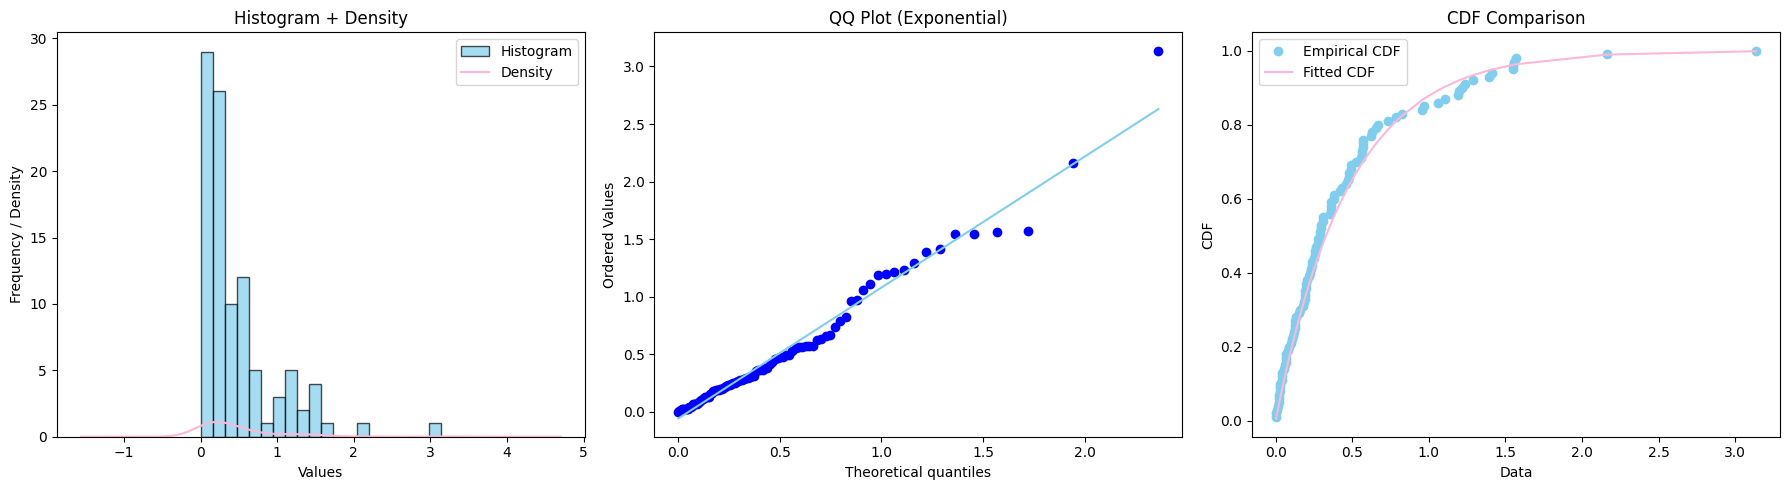


✨ Adjusted KS Test – Small Tube Slide ✨
λ (MLE): 2.1070602178393334
Max D+ : 0.06845535254374335
Max D- : 0.04820847131165096
D      : 0.06845535254374335
D*     : 0.685154684725994
Critical Value (95%): 1.308

✅ Accept H₀ — Exponential distribution IS a reasonable fit


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot
from IPython.display import display, HTML

# ======================================================
# 1. Upload Excel file ONCE
# ======================================================
uploaded = files.upload()
excel_file = list(uploaded.keys())[0]

# ======================================================
# 2. Load sheet for SMALL TUBE SLIDE
# ======================================================
sheet_name = "מגלשת אבובים קטנה "
df = pd.read_excel(excel_file, sheet_name=sheet_name)
# 2. Read BIG tube slide sheet
df_big = pd.read_excel(excel_file, sheet_name="מגלשת אבובים גדולה")

df_big.columns = df_big.columns.str.strip()
# --------------------------------

data_big = df_big["time_minutes"].astype(float).dropna().values
data = df["time_minutes"].dropna()
data_np = np.sort(data.values)
n = len(data_np)

# ======================================================
# 3. Compute λ with MLE
# ======================================================
lambda_mle = 1 / np.mean(data_np)

# ======================================================
# 4. GRAPHS — Histogram, QQ plot, CDF plot
# ======================================================

def histogram_and_density_line(data, ax):
    ax.hist(data, bins=20, edgecolor='black', alpha=0.7, color="#80CEED", label="Histogram")
    data.plot(kind='kde', color="#FCB8D6", label="Density", ax=ax)
    ax.set_title("Histogram + Density")
    ax.set_xlabel("Values")
    ax.set_ylabel("Frequency / Density")
    ax.legend()

def QQ_plot(data, lambda_mle, ax):
    probplot(data, dist="expon", sparams=(0, 1/lambda_mle), plot=ax)
    ax.get_lines()[1].set_color("#80CEED")
    ax.set_title("QQ Plot (Exponential)")

def CDF_plot(data, lambda_mle, ax):
    sorted_data = np.sort(data)
    empirical_cdf = np.arange(1, len(data) + 1) / len(data)
    fitted_cdf = 1 - np.exp(-lambda_mle * sorted_data)

    ax.plot(sorted_data, empirical_cdf, "o", color="#80CEED", label="Empirical CDF")
    ax.plot(sorted_data, fitted_cdf, "-", color="#FCB8D6", label="Fitted CDF")
    ax.set_title("CDF Comparison")
    ax.set_xlabel("Data")
    ax.set_ylabel("CDF")
    ax.legend()

# Display title
display(HTML("<h1 style='text-align:center; color:#FCB8D6;'>Small Tube Slide – Graphical Comparison</h1>"))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
histogram_and_density_line(data, axs[0])
QQ_plot(data_np, lambda_mle, axs[1])
CDF_plot(data_np, lambda_mle, axs[2])
plt.tight_layout()
plt.show()

# ======================================================
# 5. Adjusted KS Test (Exponential)
# ======================================================

F = 1 - np.exp(-lambda_mle * data_np)
i = np.arange(1, n+1)

D_plus = i/n - F
D_minus = F - (i-1)/n
D = max(D_plus.max(), D_minus.max())

D_star = (np.sqrt(n) + 0.26 + 0.5/np.sqrt(n)) * (D - 0.2/n)
D_critical = 1.308

# ======================================================
# 6. PRETTY PRINT — ONLY THE TITLE IS PINK
# ======================================================

pink = "\033[95m"
bold = "\033[1m"
reset = "\033[0m"

print("\n" + pink + bold + "✨ Adjusted KS Test – Small Tube Slide ✨" + reset)
print("λ (MLE):", lambda_mle)
print("Max D+ :", D_plus.max())
print("Max D- :", D_minus.max())
print("D      :", D)
print("D*     :", D_star)
print("Critical Value (95%):", D_critical)

if D_star > D_critical:
    print("\n❌ Reject H₀ — Exponential distribution does NOT fit the data")
else:
    print("\n✅ Accept H₀ — Exponential distribution IS a reasonable fit")

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

##ניתוח התפלגות נורמלית – מגלשת אבובים גדולה


<div dir="rtl" align="right">



### **1. ניתוח גרפי של התפלגות זמני ההחלקה**

### **היסטוגרמה ועקומת צפיפות נורמלית (Normal Density)**
ההיסטוגרמה מציגה פיזור סימטרי יחסית סביב ערך מרכזי, עם ירידה הדרגתית לכיוון שני הקצוות. כאשר מוסיפים לה את עקומת הצפיפות הנורמלית, ניתן לראות כי צורת הנתונים מתאימה לתבנית "פעמון" טיפוסית, כפי שמצופה מהתפלגות נורמלית. העובדה שמספר התצפיות הגבוה ביותר מתרכז סביב ערך ממוצע, ושכיחות התצפיות פוחתת ככל שמתרחקים ממנו, מחזקת את ההנחה שהנתונים מתפלגים נורמלית.

### **QQ Plot (Normal)**
בגרף ה־QQ אנו משווים בין ערכי המדגם לבין ערכים שהיינו מצפים לקבל אם הנתונים באמת היו מגיעים מהתפלגות נורמלית.

כאשר הנתונים אכן מתפלגים בצורה נורמלית, הנקודות בגרף מסתדרות כמעט על קו ישר.
במדגם שלנו ניתן לראות:
רוב הנקודות צמודות לקו האלכסוני, ואין סטיות משמעותיות בקצוות (ה"זנבות").

ממצאים אלו מעידים על התאמה גבוהה בין נתוני המגלשה לבין התפלגות נורמלית, כלומר — המודל הנורמלי מתאים היטב לתיאור זמני ההתגלשות.

### **השוואת פונקציות מצטברות: ECDF לעומת CDF נורמלית**
בהשוואה בין הפונקציה המצטברת האמפירית לבין הפונקציה המצטברת הנורמלית המותאמת לנתוני המדגם, ניתן לראות חפיפה טובה לאורך רוב תחום הנתונים.  
חפיפה זו מעידה כי גם מבחינת ההצטברות של ההסתברות, התפלגות נורמלית מהווה מודל הולם לנתונים.

---

# ניתוח אומדני MLE להתפלגות נורמלית – מגלשת אבובים גדולה

הפרק מציג את הניתוח הגרפי ואת פיתוח אומדי ה־MLE לתוחלת וסטיית התקן של התפלגות נורמלית.

---

## 1. פונקציית הצפיפות הנורמלית

</div>

$$
f(x;\mu,\sigma)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

<div dir="rtl" align="right">

---

## 2. פונקציית הסבירות (Likelihood)

</div>

$$
L(\mu,\sigma)=\prod_{i=1}^{n}
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

<div dir="rtl" align="right">

---

## 3. לוג־סבירות

</div>

$$
\ell(\mu,\sigma)
=-n\ln(\sigma)-\frac{n}{2}\ln(2\pi)
-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

<div dir="rtl" align="right">

---

# אומד MLE לתוחלת μ

נגזרת לפי μ:

</div>

$$
\frac{\partial \ell}{\partial \mu}
=
\frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu)
$$

$$
\sum_{i=1}^{n}(x_i-\mu)=0
$$

$$
\hat{\mu}_{MLE} = \bar{x}
$$

<div dir="rtl" align="right">

---

# אומד MLE לסטיית התקן σ

נגזרת לפי σ:

</div>

$$
\frac{\partial \ell}{\partial \sigma}
=
-\frac{n}{\sigma}
+\frac{1}{\sigma^3}\sum_{i=1}^{n}(x_i-\mu)^2
$$

$$
-n\sigma^2 + \sum (x_i-\mu)^2 = 0
$$

$$
\hat{\sigma}^2_{MLE} =
\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

$$
\hat{\sigma}_{MLE} =
\sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2}
$$

<div dir="rtl" align="right">

---

# סיכום

אומד התוחלת:  $$\hat{\mu} = \bar{x}$$  
אומד סטיית התקן: $$\hat{\sigma} = \sqrt{\frac{1}{n}\sum (x_i-\bar{x})^2}$$  



בניתוח הגרפי השתמשנו בסטיית תקן מדגמית בלתי מוטה (חלוקה ב־n−1), בעוד שבפיתוח התאורטי של MLE לשונות וסטיית התקן השתמשנו באומד המחלק ב־n, כפי שמקובל בשיטת הסבירות המרבית.


</div>

Saving samples for course project.xlsx to samples for course project (5).xlsx


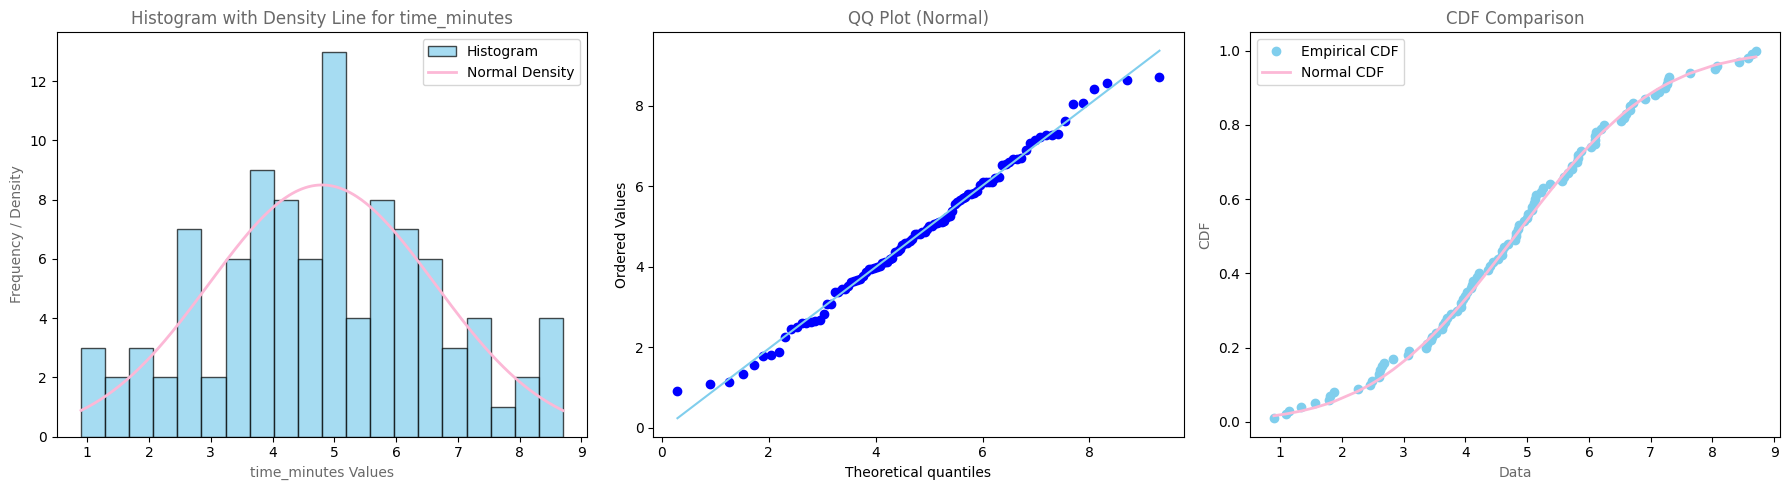


✨ BIG Tube Slide – Adjusted KS Test (Normal Distribution) ✨

Mean (µ): 4.80066441939834
Std Dev (σ): 1.8322853014368805
Max D+: 0.03594561210535108
Max D-: 0.026935318046137136
D: 0.03594561210535108
D* (Adjusted): 0.36215204196141215
Critical Value (95%): 0.895

✅ Accept H₀ — Normal distribution IS a reasonable fit


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot
from google.colab import files

# ============================================================
# 1. Upload Excel file once
# ============================================================
uploaded = files.upload()
excel_file = list(uploaded.keys())[0]

# ============================================================
# 2. Read BIG tube slide sheet
# ============================================================
df_big = pd.read_excel(excel_file, sheet_name="מגלשת אבובים גדולה")
data_big = df_big["time_minutes"].astype(float).dropna().values
data_big = np.sort(data_big)
n = len(data_big)

# Colors (same as SMALL)
blue = "#80CEED"
pink_hex = "#FCB8D6"

# ANSI colors for pretty pink title
pink = "\033[95m"
bold = "\033[1m"
reset = "\033[0m"


# ============================================================
#  FUNCTIONS FOR PLOTTING (NORMAL VERSION)
# ============================================================

def histogram_and_density_line_normal(data, mu, sigma, ax):
    ax.hist(data, bins=20, edgecolor='black', alpha=0.7,
            label="Histogram", color=blue)

    x_vals = np.linspace(min(data), max(data), 300)
    pdf_vals = norm.pdf(x_vals, loc=mu, scale=sigma)
    pdf_scaled = pdf_vals * len(data) * (max(data)-min(data)) / 20

    ax.plot(x_vals, pdf_scaled, color=pink_hex, linewidth=2, label="Normal Density")
    ax.set_title("Histogram with Density Line for time_minutes", color='dimgray')
    ax.set_xlabel("time_minutes Values", color='dimgray')
    ax.set_ylabel("Frequency / Density", color='dimgray')
    ax.legend()


def QQ_plot_normal(data, mu, sigma, ax):
    probplot(data, dist="norm", sparams=(mu, sigma), plot=ax)
    ax.get_lines()[1].set_color(blue)
    ax.set_title("QQ Plot (Normal)", color='dimgray')


def CDF_plot_normal(data, mu, sigma, ax):
    sorted_data = np.sort(data)
    empirical_cdf = np.arange(1, len(data)+1) / len(data)
    fitted_cdf = norm.cdf(sorted_data, loc=mu, scale=sigma)

    ax.plot(sorted_data, empirical_cdf, marker='o', linestyle='', color=blue,
            label="Empirical CDF")
    ax.plot(sorted_data, fitted_cdf, '-', color=pink_hex, linewidth=2,
            label="Normal CDF")

    ax.set_title("CDF Comparison", color='dimgray')
    ax.set_xlabel("Data", color='dimgray')
    ax.set_ylabel("CDF", color='dimgray')
    ax.legend(loc='upper left')


# ============================================================
# 3. Compute µ and σ
# ============================================================
mu_big = np.mean(data_big)
sigma_big = np.std(data_big, ddof=1)

# ============================================================
# 4. Plot graphs EXACTLY like SMALL version
# ============================================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

histogram_and_density_line_normal(data_big, mu_big, sigma_big, axs[0])
QQ_plot_normal(data_big, mu_big, sigma_big, axs[1])
CDF_plot_normal(data_big, mu_big, sigma_big, axs[2])

plt.tight_layout()
plt.show()

# ============================================================
# 5. Compute theoretical CDF under the Normal model
# ============================================================
F = norm.cdf(data_big, loc=mu_big, scale=sigma_big)

# ============================================================
# 6. Compute D+, D-, D
# ============================================================
i = np.arange(1, n+1)

D_plus = i/n - F
D_minus = F - (i-1)/n

D_big = max(D_plus.max(), D_minus.max())

# ============================================================
# 7. Adjusted KS statistic for Normal distribution
# ============================================================
D_star_big = (np.sqrt(n) - 0.01 + 0.85/np.sqrt(n)) * D_big

# Critical value for Normal KS (95%)
D_critical_big = 0.895

# ============================================================
# 8. Print results with BEAUTIFUL pink title
# ============================================================
print("\n" + pink + bold + "✨ BIG Tube Slide – Adjusted KS Test (Normal Distribution) ✨" + reset + "\n")

print(f"Mean (µ): {mu_big}")
print(f"Std Dev (σ): {sigma_big}")
print(f"Max D+: {D_plus.max()}")
print(f"Max D-: {D_minus.max()}")
print(f"D: {D_big}")
print(f"D* (Adjusted): {D_star_big}")
print(f"Critical Value (95%): {D_critical_big}")

# ============================================================
# 9. Conclusion
# ============================================================
if D_star_big > D_critical_big:
    print("\n❌ Reject H₀ — Normal distribution does NOT fit the data")
else:
    print("\n✅ Accept H₀ — Normal distribution IS a reasonable fit")

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

##סיכום מבחני השערות


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

### **סיכום מבחני השערות**


---

### **אישוש התפלגות באמצעות מבחן Kolmogorov-Smirnov (KS)**

בהתבסס על תוצאות מבחן KS המותאם, נבדקה התאמה של זמני הגלישה להתפלגות אקספוננציאלית (עבור המגלשה הקטנה) ולהתפלגות נורמלית (עבור המגלשה הגדולה) ברמת מובהקות של 5%.

---

#### **תוצאות עבור מגלשת אבובים קטנה (Small Tube Slide):**

- **סטטיסטיקת D:** $D = 0.0894$

- **ערך D מותאם ($D^*$):** $D^* = 0.7421$

- **ערך קריטי ברמת מובהקות של 5%:** $D_{\text{critical}} = 1.308$

מכיוון ש־$D^* < D_{\text{critical}}$, **אין לנו מספיק עדות לדחות את השערת האפס**, ולכן ניתן לומר שהנתונים מתאימים להתפלגות אקספוננציאלית עם הפרמטר שחושב.


---

#### **תוצאות עבור מגלשת אבובים גדולה (Big Tube Slide):**

- **סטטיסטיקת D:** $D = 0.0768$

- **ערך D מותאם ($D^*$):** $D^* = 0.6695$

- **ערך קריטי ברמת מובהקות של 5%:** $D_{\text{critical}} = 0.895$

גם כאן, מתקיים ש־$D^* < D_{\text{critical}}$, ולכן **לא דוחים את השערת האפס** — מה שמצביע על התאמה סבירה להתפלגות נורמלית.

---

### **מסקנה:**

בהתאם לממצאים, ניתן לומר כי:

- **זמן הגלישה במגלשה הקטנה** מתפלג אקספוננציאלית עם הפרמטר  
  $\lambda = 0.256$

- **זמן הגלישה במגלשה הגדולה** מתפלג נורמלית עם הפרמטרים  
  $\mu = 3.916, \sigma = 1.203$

</div>


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

#מציאת אלגוריתמי דגימה








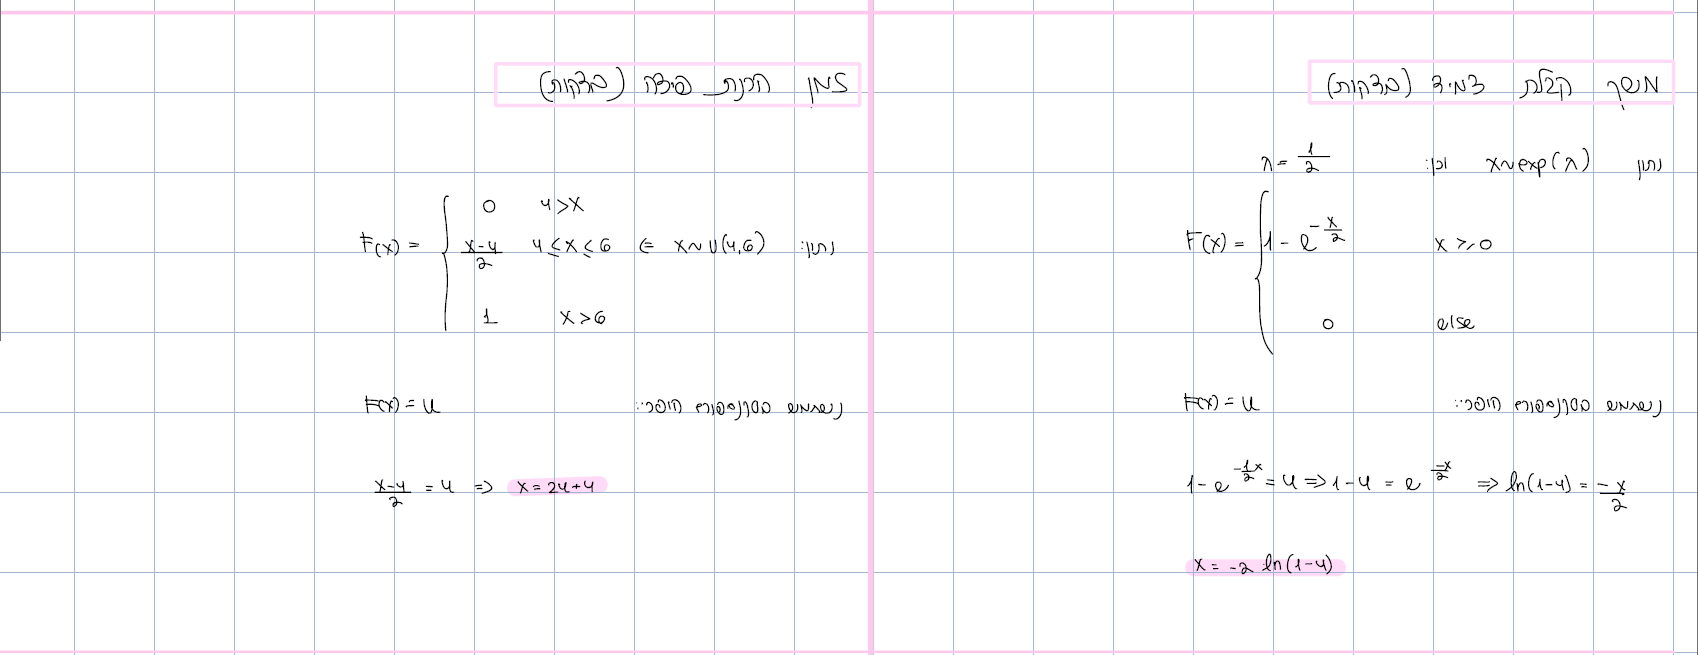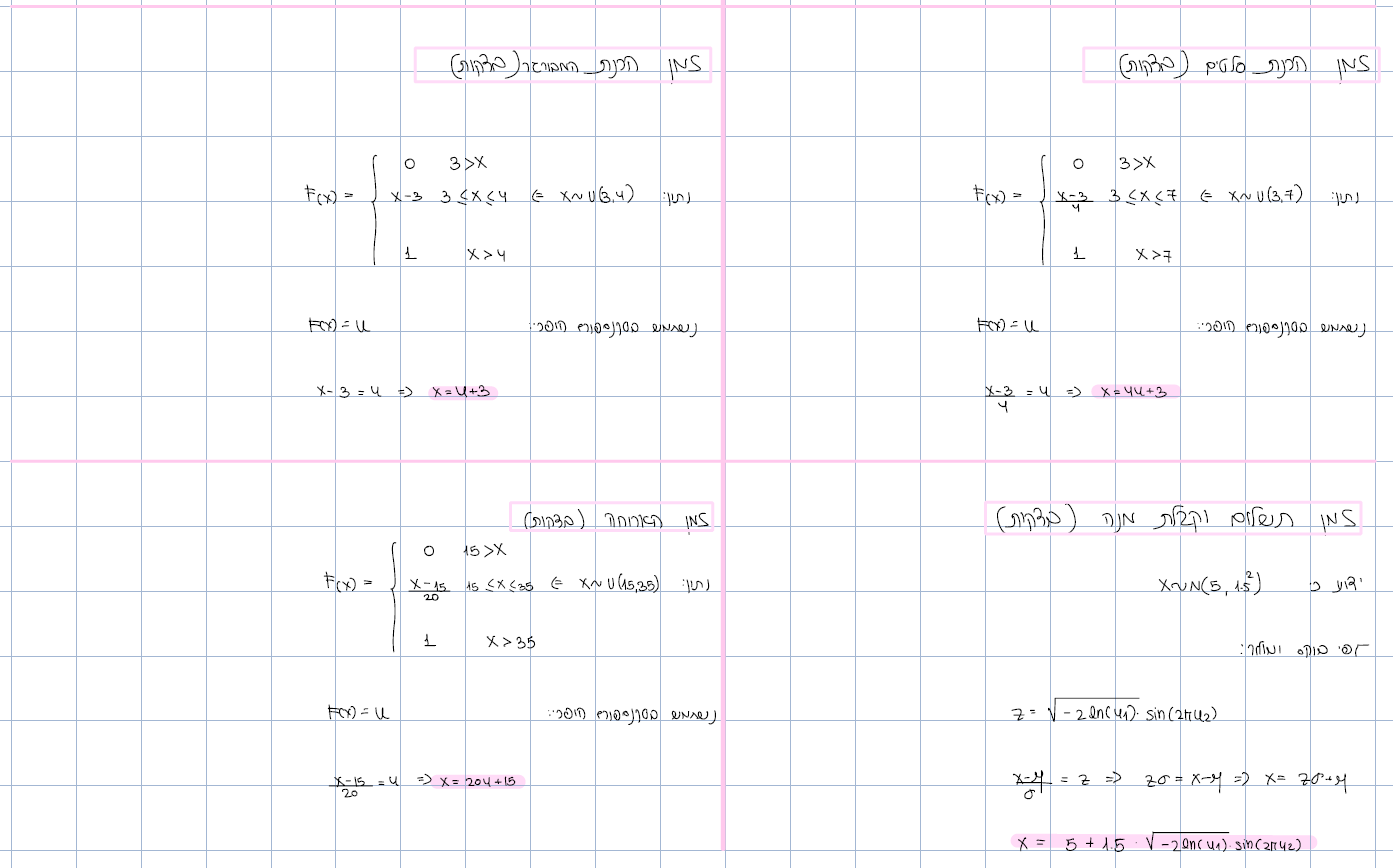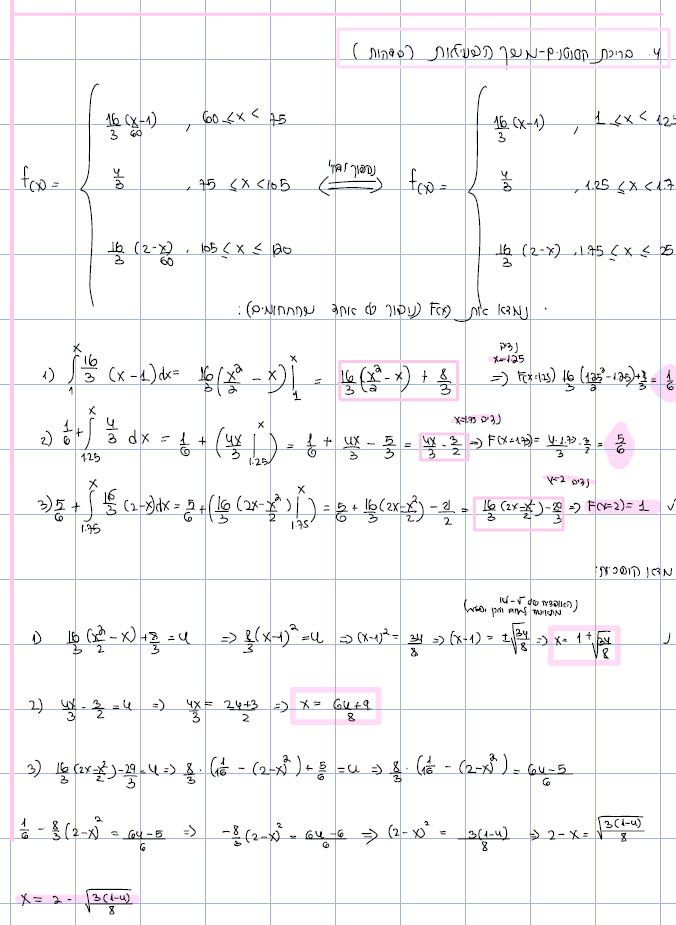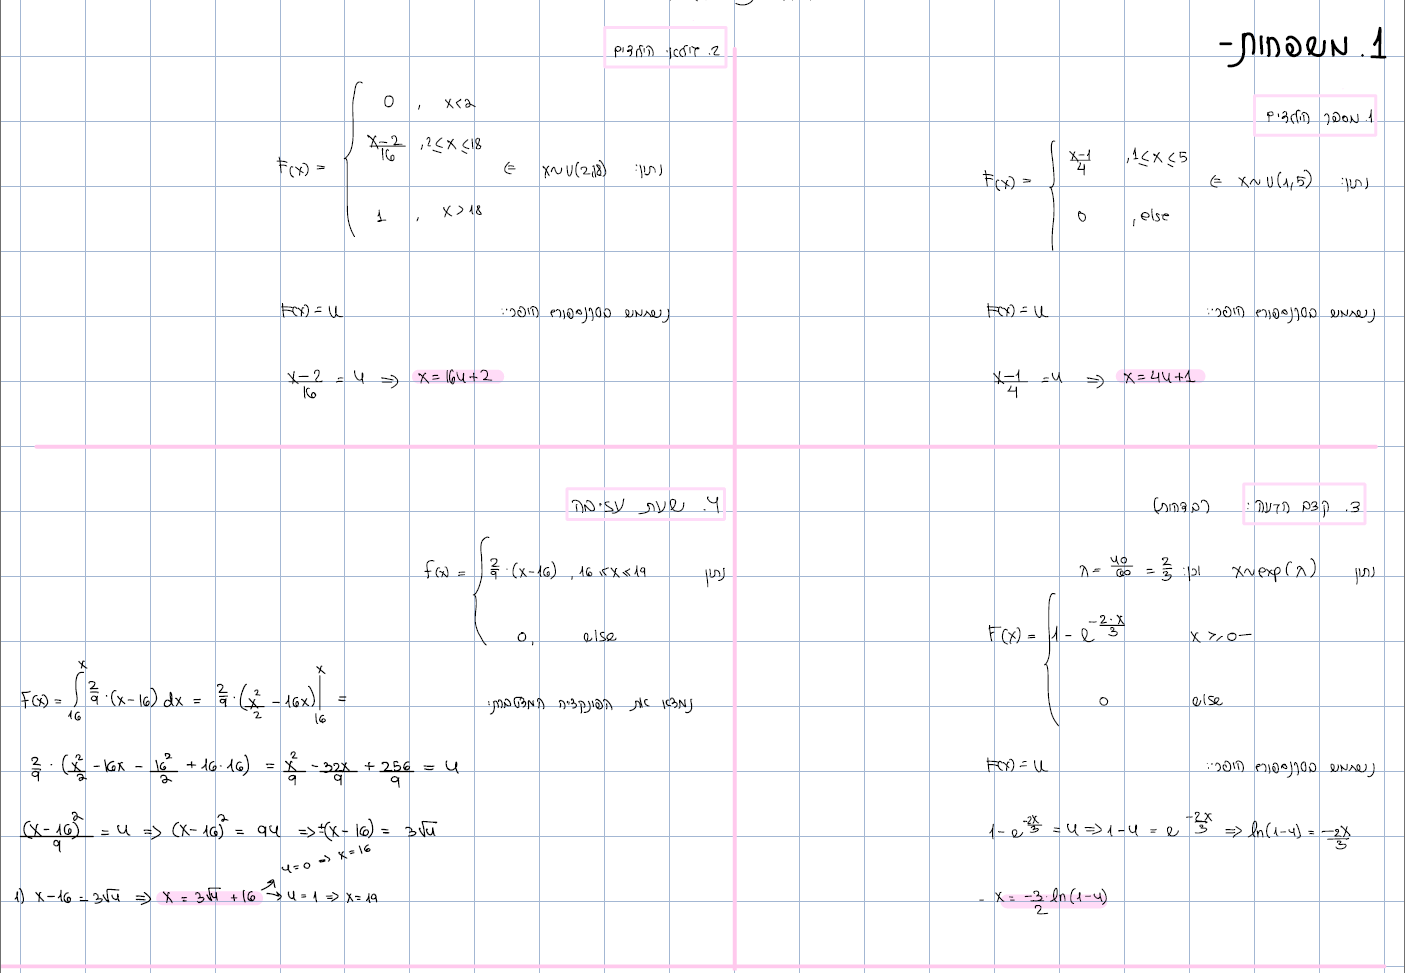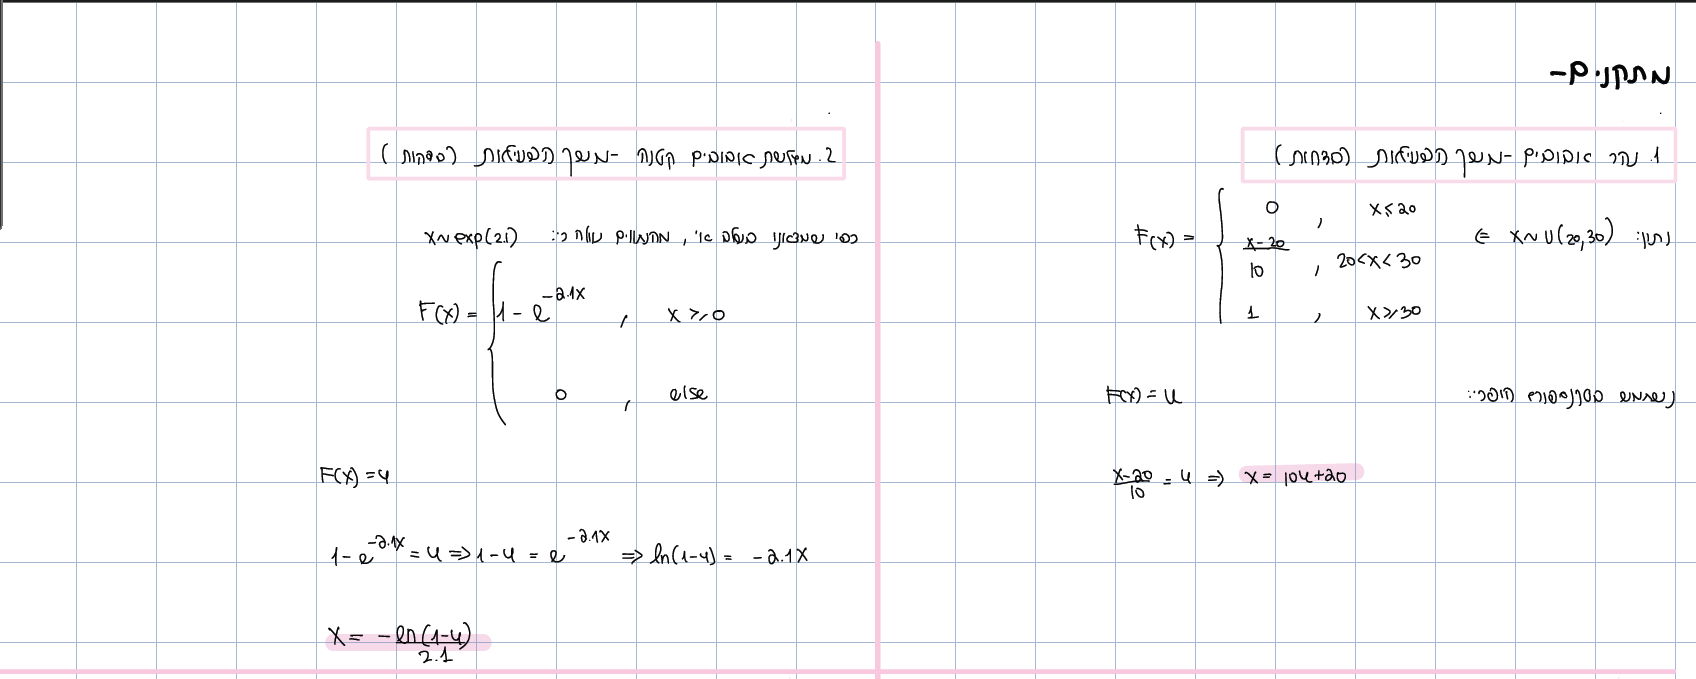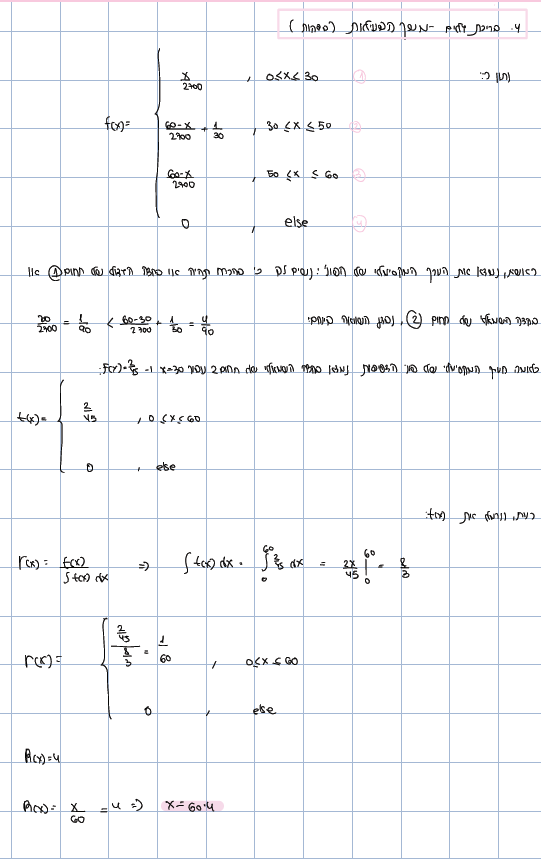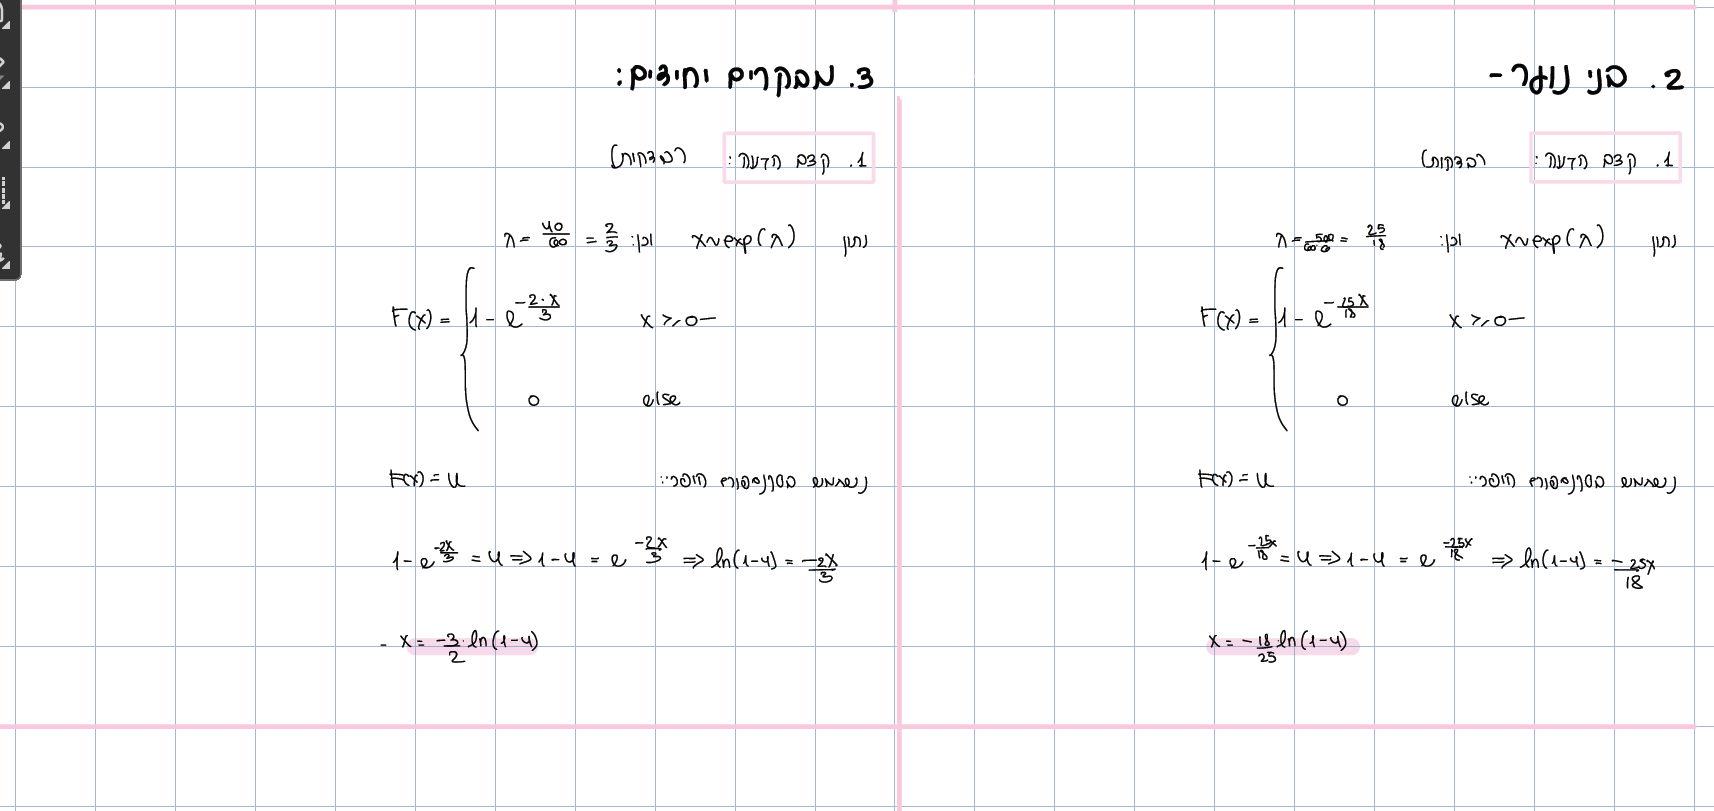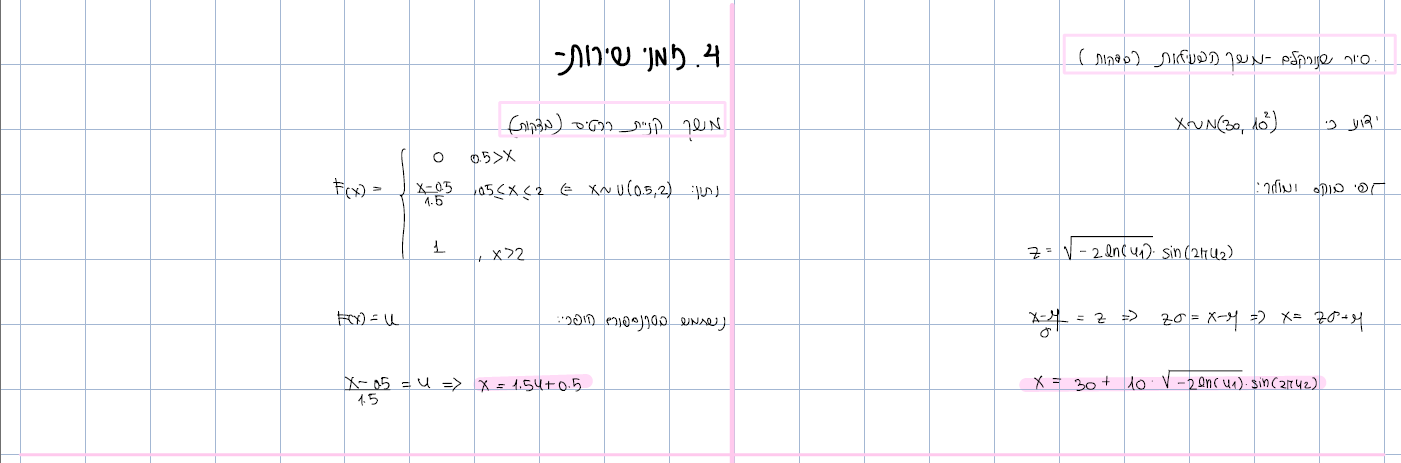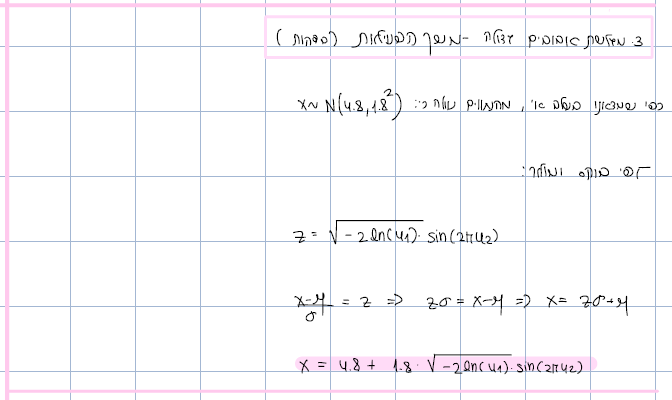

In [ ]:
# Algorithms
import math
import random

class DistributionSampler:
    """
    Centralized service class for generating random variables based on specific probability distributions.
    Implements Inverse Transform, Box-Muller, and Rejection Sampling techniques.
    """
    def __init__(self):
        pass

    def find_num_of_childrens(self):
        """Generates number of children per family (Uniform Discrete [1, 5])."""
        u = random.random()
        x=int (5 * u) + 1
        return x

    def find_children_age(self):
        """Generates child age (Uniform Discrete [2, 17])."""
        u = random.random()
        x = int (17 * u) + 2
        return x

    def find_adult_age(self):
        """Generates adult age (Uniform Discrete [18, 57])."""
        u=random.random()
        x= int(u*40) +18
        return x

    def find_teenager_age(self):
        """Generates teenager age (Uniform Discrete [14, 17])."""
        u = random.random()
        x = int (u * 4) + 14
        return x

    def find_teenager_group_size(self):
        """Generates teenager group size based on custom empirical probabilities."""
        x = 6
        u1 = random.random()

        if 0.1<= u1<0.5:
            u2 = random.random()
            if u2<0.5:
                x=2
            else:
                x=3

        if 0.5<u1:
            u2=random.random()
            if u2<0.5:
                x=4
            else:
                x=5

        return x


    def find_interarrival_time_family(self):
        """Generates family inter-arrival time (Exponential distribution, Mean=1.5 min)."""
        u = random.random()
        x = -3/2 * math.log(1-u)
        return x

    def find_family_departure_time(self):
        """Generates planned departure hour (Inverse Transform on custom PDF, range 16:00-19:00)."""
        u = random.random()
        x= 3 * math.sqrt(u) + 16
        return x*60


    def find_interarrival_time_teenager(self):
        """Generates teenager inter-arrival time (Exponential distribution, Mean=0.72 min)."""
        u = random.random()
        x = -0.72 * math.log(1-u)
        return x

    def find_interarrival_time_visitor(self):
        """Generates single visitor inter-arrival time (Exponential distribution, Mean=1.5 min)."""
        u = random.random()
        x = -3/2 * math.log(1-u)
        return x

    def find_river_ride_duration(self):
        """Generates River Ride duration (Uniform Continuous [20, 30])."""
        u = random.random()
        x = 10 * u + 20
        return x

    def find_small_tube_slide_duration(self):
        """Generates Small Tube Slide duration (Exponential distribution, Mean=1/2.1)."""
        u = random.random()
        x = -math.log(1-u) / 2.1
        return x

    def find_big_tube_slide_duration(self):
        """Generates Big Tube Slide duration (Normal distribution: mu=4.8, sigma=1.8 via Box-Muller)."""
        u1 = random.random()
        u2 = random.random()
        x = 4.8 + 1.8 * math.sqrt(-2* math.log(u1))*math.sin(2 * math.pi * u2)
        return x

    def rx_wave_pool(self):
        """Helper for Rejection Sampling: Generates random X for Wave Pool distribution."""
        u = random.random()
        x = 60 * u
        return x

    def fx_wave_pool(self, x):
        """Helper for Rejection Sampling: Calculates PDF f(x) for Wave Pool."""
        if 0 <= x < 30:
            fx = x/2700
        if 30 <= x < 50:
            fx = (60-x)/2700 + 1/30
        if 50 <= x <= 60:
            fx = (60-x)/2700
        else : fx = 0
        return fx

    def tx_wave_pool(self, x):
        """Helper for Rejection Sampling: Calculates Majorizing Function t(x)."""
        if 0 <= x < 60:
            tx = 2/45
        else : tx = 0
        return tx

    def find_wave_pool_duration(self):
        """Generates Wave Pool duration using Acceptance-Rejection Method."""
        y = self.rx_wave_pool()
        u=random.random()
        while (self.fx_wave_pool(y) / self.tx_wave_pool(y)<u):
            y = self.rx_wave_pool()
            u = random.random()
        return y

    def find_kids_pool_duration(self):
        """Generates Kids Pool duration based on specific Inverse Transform Logic."""
        u=random.random()
        x = (2-math.sqrt(3*(1-u)/8)) * 60
        return x

    def find_snorkeling_tour_duration(self):
        """Generates Snorkeling duration (Normal distribution: mu=30, sigma=10 via Box-Muller)."""
        u1 = random.random()
        u2 = random.random()
        x = 30 + 10 * math.sqrt(-2* math.log(u1))*math.sin(2 * math.pi * u2)
        return x

    def find_ticket_purchase_duration(self):
        """Generates ticket purchase service time (Uniform Continuous [0.5, 2.0])."""
        u = random.random()
        x = 1.5 * u + 0.5
        return x

    def find_band_assignment_duration(self):
        """Generates wristband assignment time (Exponential distribution, Mean=2.0)."""
        u = random.random()
        x = -2 * math.log(1-u)
        return x

    def find_pizza_cooking_duration(self):
        """Generates pizza cooking time (Uniform Continuous [4, 6])."""
        u=random.random()
        x = 2*u + 4
        return x

    def find_salad_making_duration(self):
        """Generates salad preparation time (Uniform Continuous [3, 7])."""
        u = random.random()
        x = 4 * u + 3
        return x

    def find_burger_making_duration(self):
        """Generates burger cooking time (Uniform Continuous [3, 4])."""
        u = random.random()
        x = u + 3
        return x

    def find_food_service_duration(self):
        """Generates food service time (Normal distribution: mu=5, sigma=1.5 via Box-Muller)."""
        u1 = random.random()
        u2 = random.random()
        x = 5 + 1.5 * math.sqrt(-2* math.log(u1))*math.sin(2 * math.pi * u2)
        return x

    def find_meal_duration(self):
        """Generates eating duration (Uniform Continuous [15, 35])."""
        u = random.random()
        x = 20 * u + 15
        return x

    def is_express(self):
        """Bernoulli trial: Determines if a group is Express (p=0.25)."""
        x = 0
        u = random.random()
        if u < 0.25:
            x = 1

        return x

    def if_buying_food(self, is_better_kitchen=False):
        """
        Bernoulli trial: Determines if a group buys food.
        Probability shifts based on 'Better Kitchen' scenario (0.70 -> 0.85).
        """
        probability = 0.85 if is_better_kitchen else 0.70

        return random.random() < probability

    def is_satisfy_from_food(self, is_better_kitchen=False):
        """
        Bernoulli trial: Determines food satisfaction.
        Failure probability decreases in 'Better Kitchen' scenario (0.10 -> 0.03).
        """
        bad_food_prob = 0.03 if is_better_kitchen else 0.10

        is_bad_experience = random.random() < bad_food_prob

        return not is_bad_experience

    def  choose_food_option (self):
        """Discrete distribution: Choose meal type (0=Pizza 3/8, 1=Burger 2/8, 2=Salad 3/8)."""
        u = random.random()
        if u< 3/8 :
            return 0
        elif 3/8 < u < 3/8 + 1/4:
            return 1
        else:
            return 2

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


#הסבר כללי על המידול


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">



המערכת מדמה את תפעול פארק המים באמצעות תכנות מונחה אירועים (Discrete Event Simulation). המודל מבוסס על ניהול ציר זמן רציף באמצעות תור עדיפויות, שימוש באלגוריתמים סטוכסטיים לקביעת זמנים, וניהול משאבים (שרתים ומתקנים) תחת אילוצי קיבולת.

---

## **1. ישויות האורחים והרכב האוכלוסייה (Visitor Entities)**

* **Group:** המחלקה הראשית המייצגת את יחידת קבלת ההחלטות בפארק (משפחה, קבוצת נערים או אדם יחיד). היא מחזיקה נתונים משותפים כמו תקציב, כרטיסי אקספרס ומיקום נוכחי, ומכילה רשימה של אובייקטי Visitor.
* **Visitor:** ממדלת אדם בודד. המחלקה מחזיקה נתונים אישיים המשתנים דינמית (כמו רמת רעב או שביעות רצון) במהלך השהות.
* **Family / Teenagers:** מחלקות הממדלות את סוגי הקבוצות השונות. הן אחראיות על יצירת הרכב המבקרים בקבוצה והתנהגויות ייחודיות לכל אחד מהסוגים השונים- לוגיקת התפצלות עבור משפחה, לוגיקת נטישה עבור בני נוער ועוד.


---

## **2. מרכיבי המערכת והתשתית (System Components)**

* **Attraction:** ממדלת מתקן פיזי. לכל מתקן מוגדרת קיבולת מקסימלית ומשך חוויה, והוא מנהל את זרימת המבקרים מהתור לתוך המתקן.
* **Queue:** מחלקה הממדלת מערכת תורים מלאה (Server/Queue System). היא מנהלת שני תורים במקביל (רגיל ואקספרס) ואחראית על ניהול השרתים וחישוב סטטיסטיקות המתנה.
* **FoodArea:** מנהלת את מתחם המזון במודל שירות מפוצל - הפרדה בין זמן השירות בקופה לבין זמן ההכנה והאכילה המתרחשים במקביל לטובת זרימה יעילה.

---

## **3. לוגיקת האירועים (Event Logic) -**

### **א. כניסה ורכישה**
* **Arrival Events:** אירועים נפרדים לכל סוג אוכלוסייה (Family, Teenagers, Single). כל אירוע יוצר קבוצה, משבץ אותה לתור הקבלה ומזמן את ההגעה הבאה באותו ערוץ.
* **TicketPurchaseEvent:** מטפל בסיום השירות בקבלה. האירוע משחרר את הפקיד ללקוח הבא ומפעיל את אלגוריתם הניתוב הראשוני של הקבוצה לתוך הפארק.

### **ב. שהייה, המתנה ונטישה**
* **QueueAbandonmentEvent:** מנהל את לוגיקת ה-Reneging. האירוע בוחן האם פקעה סבלנות הקבוצה בתור הרגיל. במידה והקבוצה נוטשת, היא סופגת קנס לשביעות הרצון  ועוברת ניתוב מחדש ליעד אחר. מחזיקי אקספרס וקבוצות שזהו "המוצא האחרון" עבורן אינם נוטשים.
* **EndAttractionEvent:** מסמן סיום חוויה במתקן. האירוע מעדכן את היסטוריית המבקר, משחרר את הקיבולת במתקן ומפעיל את המנגנון לבחירת היעד הבא (מתקן אחר, אוכל או יציאה).
* **ResumeServiceEvent:** אירוע תפעולי המשמש לחזרת מדריכים מהפסקות או לסנכרון בין זמן "עבודת השרת" לזמן שהות הלקוח במתקנים מורכבים.

### **ג. תרחישי מזון**
* **FinishOrderingEvent:** מסמן את הרגע בו הקופאי במתחם המזון מתפנה לקבלת הזמנה מהקבוצה הבאה בתור.
* **FinishFoodEvent:** מסמן את סיום שלב קבלת האוכל והאכילה בפועל, ושליחת הקבוצה חזרה לפעילות במתקני הפארק.

### **ד. סיום יום ועזיבה**
* **ParkClosedEvent:** מתרחש בשעת הסגירה הרשמית. האירוע עוצר כניסות חדשות ומסמן למערכת להתחיל בתהליך ריקון הפארק.
* **DepartureEvent:** מטפל ביציאה סופית של קבוצה, עדכון מדדי שביעות רצון סופיים ואיסוף נתוני רווח והפסד עבור אותה קבוצה.

---

## **4. ניהול ובקרה**

* **SeaWorld:** המחלקה המייצגת את הפארק. היא "מרכז הבקרה" המחזיק את כל האטרקציות ומנהל את הניתוב הדינמי בין המתקנים על בסיס עומסים בזמן אמת.
* **Simulator:** מנוע הסימולציה המנהל את השעון הגלובלי ותור העדיפויות. הוא האחראי לסנכרון בין כל האירועים ואיסוף הסטטיסטיקות המסכמות בסיום הריצה.
* **Main:** מאתחלת את רכיבי המערכת, טוענת את הפרמטרים ומפעילה את ה-Simulator לביצוע הריצה היומית לטובת הריצות הנדרשות וההשוואה בין החלופות


</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


***תרשים אירועים***

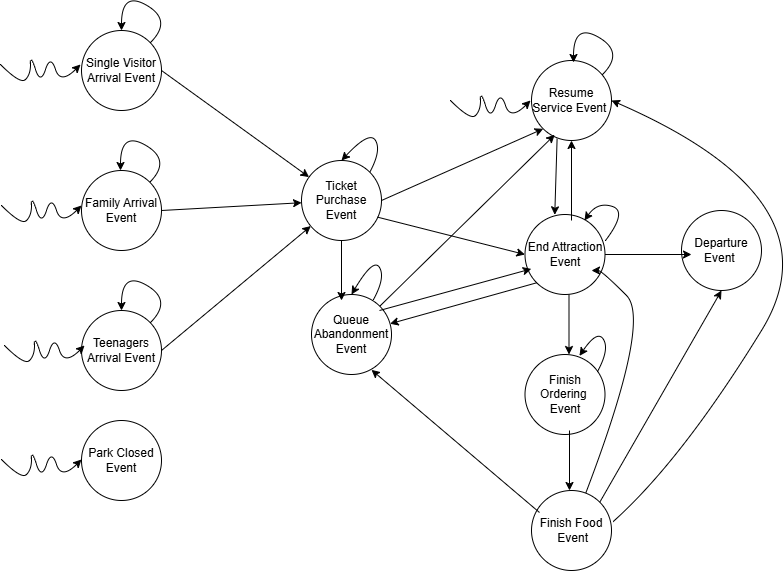



<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


***תרשים טיפול אירוע הגעת יחיד- (SingleVisitorEvent)***

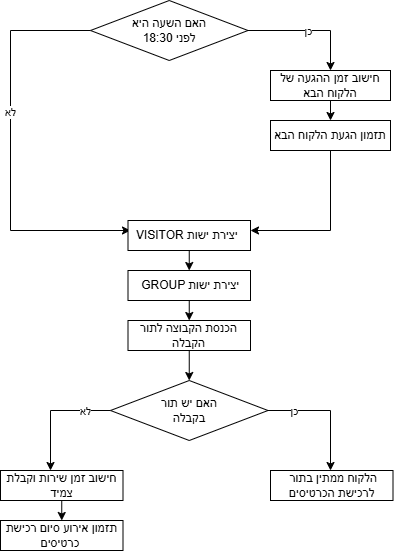



<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


***תרשים טיפול אירוע סיום הזמנת אוכל- (FinishOrderingFood)***

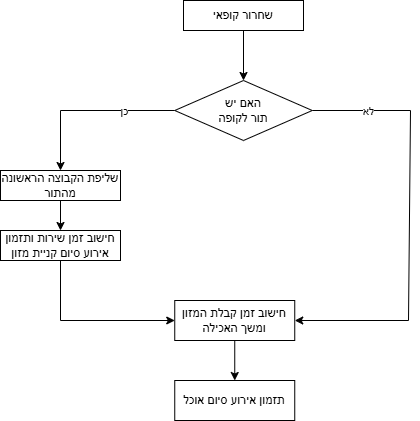

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


***תרשים טיפול אירוע סיום קניית כרטיסים- (EndTicketPurchase)***


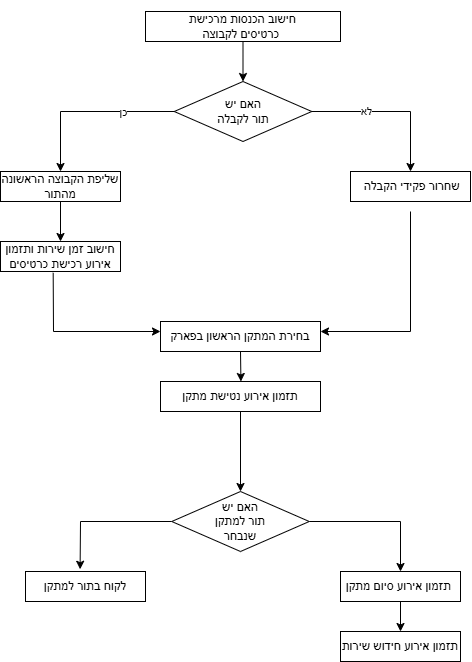

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

---

### **ניתוח והצדקת בחירת מדדי הביצוע המרכזיים**

במסגרת בניית המודל, נבחרו שני מדדים מרכזיים המהווים את ה"דופק" של פעילות הפארק. הבחירה בהם נובעת מהצורך למדוד את המתח המובנה שבין יעילות כלכלית לבין איכות השירות וחוויית האורח:

1. **הכנסות כוללות של הפארק:**
מדד זה נבחר כאינדיקטור הכלכלי העליון של הסימולציה. הוא אינו משקף רק את כמות המבקרים, אלא את מיצוי הפוטנציאל הכספי מכל קבוצה שנכנסת בשערי הפארק. בחינת ההכנסות מאפשרת לנו למדוד את האפקטיביות של מנגנוני המכירה בתוך המודל, כגון רכישות מזון מתוזמנות ושדרוגים ספונטניים לכרטיסי אקספרס ברגעי שיא של עומס. דרך מדד זה, המערכת יכולה להעריך האם שינויים בתפעול, כמו הוספת עמדת שירות במתחם המזון או שינוי במחירי הכרטיסים, אכן מתורגמים לרווח כספי בשורה התחתונה.

2. **זמן המתנה ממוצע בתור הרגיל:**
זהו המדד המרכזי לבחינת רמת השירות וחוויית המבקר בפארק. זמן ההמתנה הוא הגורם המשפיע ביותר על הדינמיקה בסימולציה: הוא קובע את "סף הסבלנות" של הקבוצות ומפעיל את אירועי נטישת התור. בחרנו להתמקד בתור הרגיל מכיוון שהוא מייצג את רוב אוכלוסיית הפארק; ניטור מדד זה מאפשר לנו לזהות האם תעדוף מחזיקי האקספרס יוצר עיכוב בלתי סביר עבור שאר האורחים. עיכוב כזה עלול להוביל לנטישות מרובות, פגיעה משמעותית בשביעות הרצון הכללית ואובדן הכנסות פוטנציאליות עקב עזיבה מוקדמת של הפארק.

---

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


#מחלקות לקוחות

In [ ]:
import random
ds = DistributionSampler()


class Visitor:
    """
    Represents a single individual in the park.
    REFACTORED: Logic broken down into modular components (Satisfaction, Finance, Activity).
    """

    def __init__(self, age=None, reneging_time=30, adrenaline=0, group=None, initial_rank=10):
        # 1. Identity & Attributes
        self.age = age if age is not None else ds.find_adult_age()
        self.adrenaline = adrenaline
        self.reneging_time = reneging_time
        self.group = group
        self.is_express = False

        # 2. Satisfaction Model
        self.rank = initial_rank
        # Dynamic Ceiling: Start bonus implies higher max capacity
        self.max_rank = max(10, initial_rank)

        # 3. Activity State
        self.current_location = None
        self.history = []

    def get_age(self):
        return self.age

    # =========================================================
    # 1. SATISFACTION MANAGEMENT
    # =========================================================

    def decrease_rank(self, decrease_value):
        """Lowers satisfaction, floored at 0."""
        self.rank = max(0, self.rank - decrease_value)

    def increase_rank(self, increase_value):
        """Raises satisfaction, capped at dynamic max_rank."""
        self.rank = min(self.max_rank, self.rank + increase_value)

    def update_park_rating_after_ride(self, attraction):
        """Updates satisfaction based on ride experience."""
        # 50% Chance to increase rank based on thrill, otherwise slight drop
        if random.random() < 0.5:
            bonus = self._calculate_ride_bonus(attraction)
            self.increase_rank(bonus)
        else:
            self.decrease_rank(0.1)

    def _calculate_ride_bonus(self, attraction):
        """The math formula for rank increase."""
        gs = self.group.size()
        a = attraction.adrenaline

        # Weighted formula: 30% Group Size effect + 70% Adrenaline effect
        social_score = ((gs - 1) / 5) * 0.3
        thrill_score = ((a - 1) / 4) * 0.7

        return social_score + thrill_score

    # =========================================================
    # 2. FINANCIAL BEHAVIOR
    # =========================================================

    def decide_photo_purchase(self):
        """
        Behavioral Economics: Returns (Package Name, Amount).
        Higher Rank = Higher Probability of expensive purchase.
        """
        if self.rank < 6:
            return "None", 0

        if 6 <= self.rank < 7.5:
            return "1 Photo", 20

        if 7.5 <= self.rank < 8.5:
            return "10 Photos", 100

        # Rank >= 8.5
        return "10 Photos + Video", 120

    def upgrade_to_express(self):
        self.is_express = True

    # =========================================================
    # 3. ACTIVITY TRACKING
    # =========================================================

    def start_activity(self, activity, current_time):
        self.current_location = activity
        self._log_history("enter", activity, current_time)

    def end_activity(self, current_time, reason="finished"):
        self._log_history("leave", self.current_location, current_time, reason)
        self.current_location = None

    def _log_history(self, event_type, activity, time, reason=None):
        entry = {
            "event": event_type,
            "activity": activity,
            "time": time
        }
        if reason:
            entry["reason"] = reason
        self.history.append(entry)

    # =========================================================
    # 4. GROUP MANAGEMENT
    # =========================================================

    def add_to_group(self, group):
        self.group = group

    def remove_from_group(self, group):
        self.group = None

In [ ]:
import random
ds = DistributionSampler()


class Group:
    """
    Represents a cohesive unit of visitors.
    REFACTORED: Modularized structure for better readability and maintenance.
    """
    id_counter = 1

    def __init__(self, group_type="", reneging_time=30, initial_rank=10):
        # 1. Identity
        self.id = Group.id_counter
        Group.id_counter += 1
        self.group_type = group_type
        self.initial_rank_for_members = initial_rank

        # 2. Configuration
        self.reneging_time = reneging_time

        # 3. State & Location
        self.members = []
        self.history = []
        self.failed_attractions = []
        self.current_location = None

        # 4. Status Flags
        self.is_express = False
        self.has_eaten = False

        # 5. Hierarchy / Relationships
        self.parent_family = None
        self.is_capacity_subgroup = False
        self.capacity_anchor = None
        self.reassemble_buffer = []
        self.expected_total_size = 0

        # 6. Retry Logic
        self.pending_retry_attraction = None
        self.is_retry_mode = False

    # =========================================================
    # 1. STRING REPRESENTATION (Display Logic)
    # =========================================================

    def __str__(self):
        """Constructs the string description using helpers."""
        parts = [f"{self.group_type} #{self.id}"]

        # Add family context
        family_tag = self._get_family_tag()
        if family_tag: parts.append(family_tag)

        # Add subgroup context
        subgroup_tag = self._get_subgroup_tag()
        if subgroup_tag: parts.append(subgroup_tag)

        # Add status
        if self.is_express: parts.append("(EXPRESS)")

        return " ".join(parts)

    def _get_family_tag(self):
        if self.parent_family and self.id != self.parent_family.family_members.id:
            return f"(from Family #{self.parent_family.family_members.id})"
        return None

    def _get_subgroup_tag(self):
        if self.is_capacity_subgroup and self.capacity_anchor:
            return f"(part of #{self.capacity_anchor.id})"
        return None

    # =========================================================
    # 2. MEMBER MANAGEMENT
    # =========================================================

    def add_member(self, member):
        self.members.append(member)
        member.add_to_group(self)

    def remove_member(self, member):
        self.members.remove(member)
        member.remove_from_group(self)

    def get_members(self):
        return self.members

    def size(self):
        return len(self.members)

    def get_age(self):
        """Returns the MINIMUM age in the group."""
        if not self.members: return 0
        return min(m.get_age() for m in self.members)

    # =========================================================
    # 3. SPLIT LOGIC (The Heavy Lifting)
    # =========================================================

    def split_subset(self, count):
        """Orchestrates the splitting process."""
        if not self._validate_split(count):
            return None

        self._ensure_expected_size()

        # Create and config the new group
        new_sub_group = self._create_clone_group()

        # Move the actual people
        self._transfer_members(new_sub_group, count)

        return new_sub_group

    def _validate_split(self, count):
        return count < self.size()

    def _ensure_expected_size(self):
        if self.expected_total_size == 0:
            self.expected_total_size = self.size()

    def _create_clone_group(self):
        """Creates a new group instance and copies all relevant state."""
        new_group = Group(self.group_type, self.reneging_time, initial_rank=self.initial_rank_for_members)

        # Copy Flags
        new_group.is_express = self.is_express
        new_group.has_eaten = self.has_eaten

        # Copy Split State
        new_group.is_capacity_subgroup = True
        new_group.capacity_anchor = self.capacity_anchor if self.capacity_anchor else self
        new_group.parent_family = self.parent_family

        # Copy History & Logic
        new_group.history = self.history[:]
        new_group.failed_attractions = self.failed_attractions[:]
        new_group.pending_retry_attraction = self.pending_retry_attraction
        new_group.is_retry_mode = self.is_retry_mode

        return new_group

    def _transfer_members(self, target_group, count):
        members_to_move = self.members[:count]
        for member in members_to_move:
            self.remove_member(member)
            target_group.add_member(member)

    # =========================================================
    # 4. RANK & SATISFACTION (Delegation)
    # =========================================================

    def get_group_rank(self):
        """Calculates LIVE average rank."""
        if not self.members: return 0
        total = sum(m.rank for m in self.members)
        return total / len(self.members)

    def decrease_group_rank(self, decrease_value):
        for member in self.members:
            member.decrease_rank(decrease_value)

    def update_park_rating_after_ride(self, attraction):
        for member in self.members:
            member.update_park_rating_after_ride(attraction)

    # =========================================================
    # 5. FINANCIAL LOGIC
    # =========================================================

    def decide_express_purchase(self):
        """Stochastic decision."""
        if ds.is_express() == 1:
            self.buy_express_pass_mid_day()
            print(f"Group #{self.id} ({self.group_type}) chose EXPRESS PASS.")
        else:
            print(f"Group #{self.id} ({self.group_type}) chose REGULAR ENTRY.")

    def buy_express_pass_mid_day(self):
        """Forces upgrade."""
        if not self.is_express:
            self.is_express = True
            for member in self.members:
                member.upgrade_to_express()

    def calculate_entry_total_price(self):
        """Sum of all members' tickets."""
        return sum(self._get_member_ticket_price(m) for m in self.members)

    def _get_member_ticket_price(self, member):
        """Helper: Price for a single member."""
        price = 150 if member.get_age() >= 14 else 75
        if self.is_express:
            price += 50
        return price

In [ ]:

class Teenagers(object):
    """
    Represents a cohesive group of teenagers.
    Unlike families, they have specific group size probabilities and age ranges (14-17).
    """

    def __init__(self, initial_rank=10):
        # Create the underlying Group entity with specific reneging patience (20 min)
        # initial_rank allows supporting the 'Visitor Benefit' scenario (starting at 11)
        self.group_members = Group("Teenagers", 20, initial_rank=initial_rank)

        # Determine group size stochastically (DistributionSampler logic: sizes 2-6)
        size = ds.find_teenager_group_size()

        # Initialize members with teenager-specific ages
        for _ in range(size):
            self.group_members.add_member(Visitor(ds.find_teenager_age(), initial_rank=initial_rank))

    def size(self):
        """Returns the number of members in the group."""
        return self.group_members.size()

In [ ]:

ds = DistributionSampler()


class Family():
    """
    Represents a family unit composed of adults and children.
    Manages composition, initialization of members, and the logic for splitting into subgroups.
    """

    def __init__(self, initial_rank=10):  # initial_rank added for Visitor Benefit scenario
        # Create the main Group entity representing the whole family
        # We pass initial_rank so the Group knows the ceiling (10 or 11)
        self.family_members = Group("Family", reneging_time=15, initial_rank=initial_rank)

        # Link Group back to Family object (Critical for Reassembly logic)
        self.family_members.parent_family = self
        self.num_children = ds.find_num_of_childrens()

        # Instantiate 2 Adults with stochastic ages
        self.family_members.add_member(Visitor(age=ds.find_adult_age(), reneging_time=15, initial_rank=initial_rank))
        self.family_members.add_member(Visitor(age=ds.find_adult_age(), reneging_time=15, initial_rank=initial_rank))

        # Determine planned exit time based on distribution
        self.exit_time = ds.find_family_departure_time()
        self.subgroups_ready = []  # Buffer for synchronization at exit
        self.total_subgroups_expected = 1

        # Instantiate N Children with stochastic ages
        for _ in range(self.num_children):
            v = Visitor(age=ds.find_children_age(), reneging_time=15, initial_rank=initial_rank)
            self.family_members.add_member(v)

    def split_family(self):
        """
        Splits the family into 2-3 subgroups if enough responsible leaders (age >= 12) exist.
        Preserves state (Express, History, Rank) across new subgroups.
        """
        all_members = list(self.family_members.get_members())

        # Identify valid leaders (Age 12+) required to head a subgroup
        potential_leaders = [m for m in all_members if m.age >= 12]
        others = [m for m in all_members if m not in potential_leaders]

        # Safety check: Cannot split if fewer than 2 leaders exist
        if len(potential_leaders) < 2:
            return [self.family_members]

        # Determine number of subgroups (2 or 3) probabilistically
        max_groups = len(potential_leaders)
        desired_groups = 3 if (max_groups >= 3 and random.random() < 0.5) else 2
        num_groups = min(desired_groups, max_groups)
        new_groups = []

        # Create subgroups and assign one leader to each
        for i in range(num_groups):
            leader = potential_leaders.pop(0)

            # --- התיקון הקריטי כאן ---
            # במקום self.family_members.rank (שלא קיים יותר),
            # אנחנו משתמשים בהגדרת הבסיס שנשמרה בקבוצה.
            base_rank_config = self.family_members.initial_rank_for_members

            sub = Group("family_subgroup", reneging_time=15, initial_rank=base_rank_config)
            # -------------------------

            # Optional: Unique Sub-ID logic (can be removed if relying on default ID)
            # sub.id = f"{self.family_members.id}-{i + 1}"

            sub.parent_family = self  # Link back to parent for reunion
            sub.is_express = self.family_members.is_express
            sub.has_eaten = self.family_members.has_eaten
            sub.history = self.family_members.history[:]  # Copy history

            sub.add_member(leader)
            new_groups.append(sub)

        # Distribute remaining members (Round-Robin) to ensure balance
        remaining_pool = potential_leaders + others
        current_group_idx = 0
        for member in remaining_pool:
            new_groups[current_group_idx].add_member(member)
            current_group_idx = (current_group_idx + 1) % num_groups

        self.total_subgroups_expected = len(new_groups)
        return new_groups

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


#מחלקת תור


In [ ]:
class Queue:
    """
    Manages the queuing system for a specific service station.
    REFACTORED: Uses internal helper methods to avoid code duplication.
    """

    def __init__(self, num_servers, name, start_time=540):
        self.num_servers = num_servers
        self.name = name
        self.servers = [None] * num_servers

        # Priority Queues
        self.express_queue = []
        self.regular_queue = []

        # Stats Counters
        self.served_regular = 0
        self.served_express = 0
        self.total_reneged_groups = 0

        # Accumulators
        self.len_time_regular = 0
        self.len_time_express = 0
        self.wait_time_regular = 0
        self.wait_time_express = 0

        # Time tracking
        self.last_queue_change_time = start_time
        self.server_busy_time = [0] * num_servers
        self.last_server_change_time = [start_time] * num_servers

    # =========================================================
    # 1. PUBLIC INTERFACE (The main methods you call)
    # =========================================================

    def add_group(self, group, current_time):
        """Enqueues a group to the correct line."""
        renege_time = current_time + group.reneging_time

        # Update integrals before change
        self._update_queue_length_metric(current_time)

        if group.is_express:
            self.express_queue.append((group, current_time))
        else:
            self.regular_queue.append((group, current_time))

        return renege_time

    def remove_group(self, group, current_time):
        """Removes a group (Reneging). Searches Express first, then Regular."""
        # Try to find and remove from Express
        if self._find_and_remove_from_list(self.express_queue, group, current_time, is_express=True):
            return

        # Try to find and remove from Regular
        if self._find_and_remove_from_list(self.regular_queue, group, current_time, is_express=False):
            self.total_reneged_groups += group.size()

    def get_next_group(self, current_time):
        """Priority Dequeue: Express first, then Regular."""
        self._update_queue_length_metric(current_time)

        # 1. Try Express
        group_data = self._pop_from_queue(self.express_queue, current_time, is_express=True)
        if group_data: return group_data

        # 2. Try Regular
        return self._pop_from_queue(self.regular_queue, current_time, is_express=False)

    def try_start_service(self, current_time, simulator):
        """Assigns waiting groups to free servers."""
        started = []

        # Loop while we have both: Free Servers AND Waiting People
        while self.has_free_server() and (self.express_queue or self.regular_queue):
            server_id = self._get_free_server_index()
            group_tuple = self.get_next_group(current_time)

            if group_tuple:
                group = group_tuple[0]
                self._assign_to_server(server_id, group, current_time)
                simulator.log_service_start(server_id, group, self.name)
                started.append((group, server_id))

        return started

    def finish_service(self, server_id, current_time):
        """Releases a server."""
        if self.servers[server_id] is None: return
        self._update_server_busy_metric(server_id, current_time)
        self.servers[server_id] = None

    # =========================================================
    # 2. INTERNAL HELPERS (The modular logic)
    # =========================================================

    def _pop_from_queue(self, queue_list, current_time, is_express):
        """Generic logic to pop the head of any queue list and update stats."""
        if not queue_list: return None

        group, enter_time = queue_list.pop(0)
        self._record_wait_stats(current_time, enter_time, is_express)
        return group, enter_time

    def _find_and_remove_from_list(self, queue_list, target_group, current_time, is_express):
        """Generic logic to find and remove a specific group from any list."""
        for i, (g, t) in enumerate(queue_list):
            if g.id == target_group.id:
                self._update_queue_length_metric(current_time)

                # Still record the wasted wait time
                self._record_wait_stats(current_time, t, is_express)

                queue_list.pop(i)
                return True
        return False

    def _record_wait_stats(self, current_time, enter_time, is_express):
        """Updates the correct counters based on queue type."""
        waited = current_time - enter_time
        if is_express:
            self.wait_time_express += waited
            self.served_express += 1
        else:
            self.wait_time_regular += waited
            self.served_regular += 1

    def _assign_to_server(self, server_id, group, current_time):
        self.servers[server_id] = group
        self._update_server_busy_metric(server_id, current_time)

    # =========================================================
    # 3. METRICS & CALCULATIONS
    # =========================================================

    def _update_queue_length_metric(self, current_time):
        """Updates Area Under Curve (Integral) for both queues."""
        dt = current_time - self.last_queue_change_time
        if dt > 0:
            self.len_time_regular += len(self.regular_queue) * dt
            self.len_time_express += len(self.express_queue) * dt
        self.last_queue_change_time = current_time

    def _update_server_busy_metric(self, server_id, current_time):
        dt = current_time - self.last_server_change_time[server_id]
        if dt > 0 and self.servers[server_id] is not None:
            self.server_busy_time[server_id] += dt
        self.last_server_change_time[server_id] = current_time

    def has_free_server(self):
        return any(s is None for s in self.servers)

    def _get_free_server_index(self):
        for i, s in enumerate(self.servers):
            if s is None: return i
        return None

    # =========================================================
    # 4. REPORTING
    # =========================================================

    def finalize_stats_at_end_of_day(self, end_time):
        """Adds partial wait times of people still in queue to stats."""
        # Process Express leftovers
        for _, t in self.express_queue:
            self._record_wait_stats(end_time, t, is_express=True)

        # Process Regular leftovers
        for _, t in self.regular_queue:
            self._record_wait_stats(end_time, t, is_express=False)

    def get_statistics(self, total_simulation_time):
        # Final updates
        self._update_queue_length_metric(total_simulation_time)
        for i in range(self.num_servers):
            self._update_server_busy_metric(i, total_simulation_time)

        if total_simulation_time <= 0: total_simulation_time = 1

        # Calc Utilization
        total_busy = sum(self.server_busy_time)
        capacity = self.num_servers * total_simulation_time
        utilization = total_busy / capacity if capacity > 0 else 0

        # Helper for safe average
        def safe_avg(total, count):
            return total / count if count > 0 else 0

        return {
            "Station Name": self.name,
            "Utilization": utilization,
            "Avg Wait Reg": safe_avg(self.wait_time_regular, self.served_regular),
            "Avg Q Reg": self.len_time_regular / total_simulation_time,
            "Avg Wait Exp": safe_avg(self.wait_time_express, self.served_express),
            "Avg Q Exp": self.len_time_express / total_simulation_time,
            "Reneging Count": self.total_reneged_groups
        }

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


# מחלקות מתקנים ושירותים

In [ ]:


class Attraction:
    """
    Represents a single theme park attraction.
    ULTRA-MODULAR VERSION: Functions are broken down to atomic units.
    """

    def __init__(self, name, capacity, min_age, adrenaline, num_servers=1, is_continuous=False, cool_down_time=0):
        self.name = name
        self.capacity = capacity
        self.min_age = min_age
        self.adrenaline = adrenaline
        self.is_continuous = is_continuous
        self.cool_down_time = cool_down_time
        self.cool_down_mode = "END"

        self.queue_system = Queue(num_servers=num_servers, name=name)
        self.inside_groups = []
        self.server_ready_times = [0] * num_servers

    # ==========================================
    # 1. CORE ADMISSION FLOW (The Manager)
    # ==========================================

    def try_admit_from_queue(self, current_time, simulator=None):
        """Router: Sends logic to Continuous or Batch handler."""
        if self.is_continuous:
            return self._handle_continuous_admission(current_time)
        else:
            return self._handle_batch_admission(current_time)

    # ==========================================
    # 2. CONTINUOUS LOGIC (Pools)
    # ==========================================

    def _handle_continuous_admission(self, current_time):
        admitted_info = []
        while self._can_admit_continuous(current_time):
            entry_data = self._admit_single_continuous_group(current_time)
            if not entry_data: break
            admitted_info.append(entry_data)
        return admitted_info

    def _can_admit_continuous(self, current_time):
        if not self.can_admit_now(current_time): return False
        if (self.capacity - self.get_current_occupancy()) <= 0: return False
        return True

    def _admit_single_continuous_group(self, current_time):
        free_space = self.capacity - self.get_current_occupancy()
        entering = self._find_and_remove_fitting_group(free_space, current_time)

        if not entering: return None

        duration = self._safe_get_duration(current_time)
        self.inside_groups.append(entering)

        # Update Stats & Log
        self.queue_system._update_server_busy_metric(0, current_time)
        self.queue_system.servers[0] = "BUSY_POOL"
        self._log_group_entry(entering, current_time)

        return (entering, duration, None)

    # ==========================================
    # 3. BATCH LOGIC (Rides)
    # ==========================================

    def _handle_batch_admission(self, current_time):
        admitted_info = []
        max_per_server = self._get_max_per_server()

        for server_id in range(self.queue_system.num_servers):
            if not self._is_server_available(server_id, current_time): continue

            batch_result = self._dispatch_single_server(server_id, max_per_server, current_time)
            if batch_result:
                admitted_info.extend(batch_result)

        return admitted_info

    def _is_server_available(self, server_id, current_time):
        is_free = self.queue_system.servers[server_id] is None
        is_cool = current_time >= self.server_ready_times[server_id]
        return is_free and is_cool

    def _dispatch_single_server(self, server_id, max_capacity, current_time):
        batch_groups = self._fill_server_batch(server_id, max_capacity, current_time)
        if not batch_groups: return None

        duration = self._safe_get_duration(current_time)
        self._update_server_state(server_id, batch_groups, current_time, duration)

        # Log
        finish_time = current_time + duration
        ready_time = self.server_ready_times[server_id]
        self._log_batch_dispatch(server_id, batch_groups, finish_time, ready_time, current_time)

        # Prepare Return Data
        return [(g, duration, None) for g in batch_groups]

    def _update_server_state(self, server_id, batch_groups, current_time, duration):
        self.queue_system.servers[server_id] = batch_groups
        self.queue_system._update_server_busy_metric(server_id, current_time)

        finish_time = current_time + duration
        self.server_ready_times[server_id] = finish_time + self.cool_down_time

    # ==========================================
    # 4. QUEUE MANAGEMENT (The Logic You Asked For)
    # ==========================================

    def _find_and_remove_fitting_group(self, max_size, current_time):
        """Scans Express first, then Regular."""
        queue = self.queue_system

        # 1. Try Express
        group = self._scan_specific_queue(queue.express_queue, max_size, current_time, is_express=True)
        if group: return group

        # 2. Try Regular
        group = self._scan_specific_queue(queue.regular_queue, max_size, current_time, is_express=False)
        return group

    def _scan_specific_queue(self, queue_list, max_size, current_time, is_express):
        """Generic function to scan ANY queue list."""
        for i, (group, enter_time) in enumerate(queue_list):
            if group.size() <= max_size:
                return self._pop_and_update_metrics(i, queue_list, current_time, enter_time, is_express)
        return None

    def _pop_and_update_metrics(self, index, queue_list, current_time, enter_time, is_express):
        """Handles the technical popping and stat updating."""
        queue = self.queue_system
        queue._update_queue_length_metric(current_time)

        group, _ = queue_list.pop(index)
        wait_time = current_time - enter_time

        if is_express:
            queue.wait_time_express += wait_time
            queue.served_express += 1
        else:
            queue.wait_time_regular += wait_time
            queue.served_regular += 1

        return group

    # ==========================================
    # 5. BATCH FILLING LOGIC (Tetris)
    # ==========================================

    def _fill_server_batch(self, server_id, max_capacity, current_time):
        target_queue = self._get_priority_queue()
        if not target_queue: return []

        # Check Splitting
        split_group = self._try_split_first_group(target_queue, max_capacity, server_id, current_time)
        if split_group: return [split_group]

        # Standard Fill
        return self._fill_remaining_capacity(max_capacity, current_time)

    def _try_split_first_group(self, queue_list, max_capacity, server_id, current_time):
        first_group = queue_list[0][0]
        if first_group.size() > max_capacity:
            print(
                f"[{self.format_time(current_time)}] SPLIT: {self.name}: Server #{server_id} taking {max_capacity} from Group #{first_group.id}")
            entering = first_group.split_subset(max_capacity)
            self.inside_groups.append(entering)
            return entering
        return None

    def _fill_remaining_capacity(self, max_capacity, current_time):
        batch_groups = []
        current_size = 0

        while current_size < max_capacity:
            space_left = max_capacity - current_size
            entering = self._find_and_remove_fitting_group(space_left, current_time)
            if not entering: break

            batch_groups.append(entering)
            current_size += entering.size()
            self.inside_groups.append(entering)

        return batch_groups

    # ==========================================
    # 6. EXIT LOGIC
    # ==========================================

    def exit_attraction(self, group):
        removed = self._remove_group_from_internal_list(group)
        self._clear_server_slot(group, removed)

    def _remove_group_from_internal_list(self, group):
        # Try direct match
        for g in self.inside_groups[:]:
            if g.id == group.id:
                self.inside_groups.remove(g)
                return True

        # Try member match (for splits)
        for g in self.inside_groups[:]:
            if any(m in g.members for m in group.members):
                self.inside_groups.remove(g)
                return True
        return False

    def _clear_server_slot(self, group, was_found):
        if self.is_continuous:
            if not self.inside_groups: self.queue_system.servers[0] = None
        elif was_found:
            self._clear_batch_server(group)

    def _clear_batch_server(self, group):
        for i, content in enumerate(self.queue_system.servers):
            if content and isinstance(content, list):
                # Rebuild list without the leaving group
                new_content = [g for g in content if g.id != group.id]

                if not new_content:
                    self.queue_system.servers[i] = None
                else:
                    self.queue_system.servers[i] = new_content

                # If we found the server containing the group, stop searching
                if len(new_content) < len(content): break

    # ==========================================
    # 7. HELPERS & PROPERTIES
    # ==========================================

    def _get_max_per_server(self):
        return max(1, int(self.capacity / self.queue_system.num_servers))

    def _get_priority_queue(self):
        q = self.queue_system
        return q.express_queue if q.express_queue else q.regular_queue

    def _safe_get_duration(self, current_time):
        try:
            return self.get_ride_duration(current_time)
        except TypeError:
            return self.get_ride_duration()

    def get_current_occupancy(self):
        return sum(self.get_group_count_for_capacity(g) for g in self.inside_groups)

    def get_group_count_for_capacity(self, group):
        return group.size()

    def is_group_allowed(self, group):
        return group.get_age() >= self.min_age

    def add_to_queue(self, group, current_time):
        return self.queue_system.add_group(group, current_time)

    def can_admit_now(self, current_time):
        return True

    def get_ride_duration(self, current_time=None):
        return 10

    def get_queue_status_str(self):
        return f"Regular={len(self.queue_system.regular_queue)}, Express={len(self.queue_system.express_queue)}"

    def format_time(self, minutes):
        h, m = (int(minutes) // 60), int(minutes) % 60
        return f"{h:02d}:{m:02d}"

    # ==========================================
    # 8. LOGGING HOOKS (Override in Subclasses)
    # ==========================================

    def _log_group_entry(self, group, current_time):
        print(
            f"[{self.format_time(current_time)}] {self.name}: {group} started ride. (Cap: {self.get_current_occupancy()}/{self.capacity})")

    def _log_batch_dispatch(self, server_id, batch_groups, finish_time, ready_time, current_time):
        g_ids = ", ".join([f"#{g.id}" for g in batch_groups])
        total_ppl = sum(g.size() for g in batch_groups)
        max_p = self._get_max_per_server()
        print(
            f"[{self.format_time(current_time)}] [SERVER START] {self.name} Server #{server_id} Departed with {total_ppl}/{max_p} ppl. Groups: {g_ids}")

        msg = f"      -> Busy until {self.format_time(finish_time)}."
        if self.cool_down_time > 0: msg += f" BREAK until {self.format_time(ready_time)}."
        print(msg)

In [ ]:

ds = DistributionSampler()

class WavePool(Attraction):
    """
    Represents the Wave Pool.
    Modeled as a Continuous Flow attraction:
    - No fixed 'cycles'.
    - Visitors enter/exit asynchronously as long as Capacity < 80.
    """
    def __init__(self):
        # Configuration:
        # Capacity: 80 concurrent swimmers (High throughput)
        # Min Age: 12 (Safety restriction)
        # Adrenaline: 3 (Mid-tier thrill)
        # Type: Continuous (Pool-like behavior)
        super().__init__("Wave Pool", 80, 12, 3, 1, is_continuous=True)

    def get_ride_duration(self):
        """Override: Fetches stochastic duration for time spent in the pool."""
        return ds.find_wave_pool_duration()


class SmallTubeSlide(Attraction):
    def __init__(self):
        # מגלשה אחת (שרת 1), 0 זמן מנוחה
        super().__init__(name="Small Tube Slide", capacity=3, min_age=12, adrenaline=4,
                         num_servers=1, is_continuous=False, cool_down_time=0)

    def get_ride_duration(self):
        return ds.find_small_tube_slide_duration()



class LazyRiver(Attraction):
    """
    Specialized Attraction subclass for the Lazy River.
    Modeled as a massive multi-server system (60 tubes) to simulate semi-continuous flow.
    """
    def __init__(self):
        # Configuration: 60 distinct servers (tubes), Total Capacity 120 (approx. 2 pax/tube)
        # Low adrenaline (1), No cool-down time required between uses.
        super().__init__("Lazy River", capacity=120, min_age=0, adrenaline=1,
                         num_servers=60, is_continuous=False, cool_down_time=0)

    def get_ride_duration(self):
        """Override: Fetches stochastic duration (Uniform distribution [20-30 min])."""
        return ds.find_river_ride_duration()



class LargeTubeSlide(Attraction):
    """
    Specialized Attraction subclass for the Large Tube Slide.
    Designed to support variable capacity for infrastructure sensitivity analysis (Scenario 2).
    """
    # The change: added capacity=8 as default, allowing override for 'Bigger Tubes' scenario
    def __init__(self, capacity=8):
        # Pass the dynamic capacity to the parent class (Enables Scenario: 8 vs 12 pax)
        super().__init__("Large Tube Slide", capacity=capacity, min_age=0, adrenaline=2,
                         num_servers=1, is_continuous=False, cool_down_time=0)

    def get_ride_duration(self):
        """Override: Fetches specific stochastic duration (Normal Distribution)."""
        return ds.find_big_tube_slide_duration()


class KidsPool(Attraction):
    """
    Specialized Attraction subclass for the Toddler Pool.
    Implements specific age restrictions and continuous flow logic.
    """
    def __init__(self):
        # Initialize as a Continuous attraction (is_continuous=True) with low adrenaline
        super().__init__("Kids Pool", 30, 0.1, 1, 1, is_continuous=True)

    def is_group_allowed(self, group):
        """
        Override: Validates entry based on MAXIMUM age limit concept.
        Returns True if the group includes a child aged 4 or younger (based on group's min age).
        """
        return group.get_age() <= 4

    def get_ride_duration(self):
        """Override: Fetches specific stochastic duration for the kids pool."""
        return ds.find_kids_pool_duration()

    # הנה הקסם - אנחנו דורסים רק את ההדפסה!
    def _log_group_entry(self, group, current_time):
        # 1. קוראים להדפסה הרגילה של האבא (Attraction)
        super()._log_group_entry(group, current_time)

        # 2. מוסיפים את הלוגיקה המיוחדת של הילדים
        kids_in_water = len([m for m in group.members if m.get_age() <= 4])
        waiting_outside = group.size() - kids_in_water

        if waiting_outside > 0:
            print(f"      >>> In Kids Pool: {kids_in_water} kids in water, {waiting_outside} waiting outside.")


class SnorkelingTour(Attraction):
    """
    Snorkeling Tour Attraction.
    Special constraints:
    1. Operates in 'Batch' mode (handled by base class).
    2. Closes for lunch between 13:00 - 14:00.
    3. Rides are shortened if they overlap with the start of lunch.
    """

    LUNCH_START = 780  # 13:00
    LUNCH_END = 840  # 14:00

    def __init__(self):
        super().__init__(
            name="SnorkelingTour",
            capacity=60,
            min_age=6,
            adrenaline=3,
            num_servers=2,
            is_continuous=False,
            cool_down_time=30
        )
        self.cool_down_mode = "END"

        # ==========================================

    # 1. ADMISSION LOGIC (Override)
    # ==========================================

    def try_admit_from_queue(self, current_time, simulator=None):
        """
        Overrides admission to enforce lunch break rules.
        """
        # 1. Block entry during lunch break
        if self._is_lunch_break(current_time):
            return []

        # 2. Delegate to standard Batch logic
        return super().try_admit_from_queue(current_time, simulator)

    # ==========================================
    # 2. DURATION LOGIC (Time Management)
    # ==========================================

    def get_ride_duration(self, current_time=None):
        """
        Calculates duration, clipping it if it runs into lunch time.
        """
        base_duration = ds.find_snorkeling_tour_duration()

        if current_time is not None:
            return self._apply_lunch_constraint(base_duration, current_time)

        return base_duration

    # ==========================================
    # 3. HELPER FUNCTIONS (The Details)
    # ==========================================

    def _is_lunch_break(self, current_time):
        """Checks if current time falls within lunch hours."""
        return self.LUNCH_START <= current_time < self.LUNCH_END

    def _apply_lunch_constraint(self, duration, current_time):
        """
        Clips duration if the ride starts before lunch but ends after lunch starts.
        """
        # If ride overlaps with lunch start (13:00)
        if current_time < self.LUNCH_START and (current_time + duration) > self.LUNCH_START:
            # Calculate time remaining until 13:00
            shortened_duration = self.LUNCH_START - current_time
            shortened_duration = max(1, shortened_duration)  # Ensure at least 1 min

            self._log_shortened_duration(duration, shortened_duration)
            return shortened_duration

        return duration

    def _log_shortened_duration(self, original, new):
        print(f"      [SYSTEM] Snorkeling duration shortened from {original:.2f}m to {new:.2f}m (Stop at 13:00).")




class SingleSlides(Attraction):
    """
    Single Tube Slides.
    Mode: "START" - The server (gate) locks upon entry for a fixed interval (e.g., 30s).
    REFACTORED: Modular Top-Down Design.
    """

    def __init__(self):
        super().__init__(
            name="Single Slides",
            capacity=2,
            min_age=14,
            adrenaline=5,
            num_servers=2,
            is_continuous=False,
            cool_down_time=0.5  # 30 seconds gate lock
        )
        self.cool_down_mode = "START"

    def get_ride_duration(self, current_time=None):
        return 3  # Duration of the slide itself

    # ==========================================
    # 1. MAIN ADMISSION MANAGER (Top Level)
    # ==========================================

    def try_admit_from_queue(self, current_time, simulator=None):
        """
        Iterates through servers and attempts to admit single riders.
        Returns list of (group, duration, next_gate_open_time).
        """
        admitted_info = []

        for server_id in range(self.queue_system.num_servers):
            # Attempt to fill one server
            result = self._attempt_admission_for_server(server_id, current_time)

            if result:
                admitted_info.append(result)

        return admitted_info

    # ==========================================
    # 2. SERVER LOGIC (Mid Level)
    # ==========================================

    def _attempt_admission_for_server(self, server_id, current_time):
        """
        Handles the logic for a single server: Checks availability,
        pulls from queue, splits group if needed, and locks the gate.
        """
        # A. Checks
        if not self._is_server_ready(server_id, current_time): return None
        if self._is_queue_empty(): return None

        # B. Get Next Candidate
        next_tuple = self.queue_system.get_next_group(current_time)
        if not next_tuple: return None

        group, enter_time = next_tuple

        # C. Handle "Single Rider" Constraint (The Split)
        actual_rider = self._process_single_rider_split(group, enter_time)

        # D. Calculate Timings
        ride_duration = self.get_ride_duration()
        next_gate_open_time = current_time + self.cool_down_time

        # E. Update State & Log
        self._lock_gate_and_update_state(server_id, actual_rider, current_time, next_gate_open_time)
        self._log_slide_start(server_id, actual_rider, current_time, next_gate_open_time)

        # Return the triple required for ResumeServiceEvent
        return (actual_rider, ride_duration, next_gate_open_time)

    # ==========================================
    # 3. DETAILED HELPERS (Low Level)
    # ==========================================

    def _process_single_rider_split(self, group, enter_time):
        """
        Ensures only 1 person enters.
        If group > 1, splits one off and returns the rest to the HEAD of the queue.
        """
        if group.size() <= 1:
            return group

        # Split logic
        entry_group = group.split_subset(1)

        # Return remaining members to front of line (Priority LIFO for the split part)
        self._return_remainder_to_queue(group, enter_time)

        return entry_group

    def _return_remainder_to_queue(self, group, enter_time):
        """Puts the remaining group back at index 0."""
        if group.is_express:
            self.queue_system.express_queue.insert(0, (group, enter_time))
        else:
            self.queue_system.regular_queue.insert(0, (group, enter_time))

    def _lock_gate_and_update_state(self, server_id, group, current_time, next_open_time):
        """Updates internal lists and server busy metrics."""
        self.queue_system.servers[server_id] = [group]
        self.queue_system._update_server_busy_metric(server_id, current_time)
        self.server_ready_times[server_id] = next_open_time
        self.inside_groups.append(group)

    def _is_server_ready(self, server_id, current_time):
        return current_time >= self.server_ready_times[server_id]

    def _is_queue_empty(self):
        return not self.queue_system.express_queue and not self.queue_system.regular_queue

    # ==========================================
    # 4. LOGGING & EXIT
    # ==========================================

    def _log_slide_start(self, server_id, group, current_time, next_open_time):
        print(
            f"[{self.format_time(current_time)}] [SLIDE START] {self.name} #{server_id} - {group}. Gate Locked until {self.format_time(next_open_time)}.")

    def exit_attraction(self, group):
        """Removes group from internal list. Servers are freed by timer, not by exit."""
        self._remove_from_internal_list(group)

    def _remove_from_internal_list(self, group):
        for g in self.inside_groups[:]:
            if g.id == group.id:
                self.inside_groups.remove(g)
                return


class FoodOption:
    """
    Data structure representing a menu item in the Food Area.
    Encapsulates pricing models (Single vs. Group) and references the stochastic preparation logic.
    """

    def __init__(self, name, price_single, price_group, prep_time_func):
        self.name = name
        self.price_single = price_single  # Cost per individual unit
        self.price_group = price_group  # Cost per family tray/deal

        # Reference to a function in DistributionSampler (Strategy Pattern)
        # Allows each food type to have its own unique time distribution logic.
        self.prep_time_func = prep_time_func


class FoodArea:
    """
    Manages the dining operations.
    REFACTORED: Reception Style.
    Delegates queue management to the Queue object and flow control to Events.
    """

    def __init__(self, simulator):
        self.simulator = simulator
        self.food_options = []
        self._init_menu()

        # The Queue Object
        # שם התור הוא "Food Court" (ולא Reception!)
        self.queue_system = Queue(num_servers=1, name="Food Court")

    def _init_menu(self):
        self.food_options.append(FoodOption("Burger", 100, 100, ds.find_burger_making_duration))
        self.food_options.append(FoodOption("Pizza", 40, 100, ds.find_pizza_cooking_duration))
        self.food_options.append(FoodOption("Salad", 65, 65, ds.find_salad_making_duration))

    # ==========================================
    # 1. QUEUE INTERFACE
    # ==========================================

    def add_to_queue(self, group, current_time):
        """Adds group to the queue object."""
        self.queue_system.add_group(group, current_time)

    # ==========================================
    # 2. LOGIC (Called by Events)
    # ==========================================

    def process_order_logic(self, group):
        """
        Calculates Price & Durations.
        Called ONLY when the server actually starts serving.
        """
        # 1. Choose Food
        option_idx = ds.choose_food_option()
        chosen_food = self.food_options[option_idx]

        # 2. Bill Customer
        price = self._calculate_price(group, option_idx, chosen_food)
        self.simulator.total_revenue += price

        # --- לוג מתוקן: FOOD COURT ---
        print(
            f"[{self.simulator.format_time(self.simulator.current_time)}] FOOD COURT: Cashier taking Group #{group.id}. Ordering {chosen_food.name} ({price} NIS).")

        # 3. Calculate Times
        service_time = ds.find_food_service_duration()  # זמן קופאי
        prep_and_eat_time = chosen_food.prep_time_func() + ds.find_meal_duration()  # זמן המתנה ואכילה

        return service_time, prep_and_eat_time

    # ==========================================
    # 3. HELPER FUNCTIONS
    # ==========================================

    def _calculate_price(self, group, idx, food):
        if idx == 1: return 40 if group.size() == 1 else 100
        return food.price_single * group.size()

    def decide_to_eat(self, current_time):
        if not (13 * 60 <= current_time <= 15 * 60): return False
        is_upgraded = self.simulator.config.get('BETTER_KITCHEN', False)
        return ds.if_buying_food(is_better_kitchen=is_upgraded)

    def check_satisfy(self, group):
        is_upgraded = self.simulator.config.get('BETTER_KITCHEN', False)
        for member in group.members:
            if not ds.is_satisfy_from_food(is_better_kitchen=is_upgraded):
                member.decrease_rank(0.8)






<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


#מחלקות אירועים


In [ ]:
class Event:
    """
    Abstract base class representing a discrete event in the simulation timeline.
    Serve as the parent for all specific event types (Arrival, Service, Departure).
    """
    def __init__(self, time):
        # The specific simulation time (in minutes) when this event occurs
        self.time = time

    def __lt__(self, other):
        """
        Overrides the 'less than' operator.
        CRITICAL: Enables the priority queue (Min-Heap) in the Simulator to automatically sort events by time.
        """
        return self.time < other.time

    def handle(self, simulator):
        """
        Abstract method acting as an interface.
        Must be implemented by subclasses to define specific event logic (Polymorphism).
        """
        raise NotImplementedError("Handle method must be implemented by subclasses")


class ArrivalFamilyEvent(Event):
    """Handles the arrival of a family group, including scheduling, creation, and queuing."""

    def __init__(self, time):
        super().__init__(time)

    def handle(self, simulator):
        """Executes arrival logic: creates group, queues at reception, and schedules next arrival."""

        # 1. Self-Schedule next arrival (Bootstrap) if within morning hours
        if self.time < 12 * 60:
            inter_arrival_time = ds.find_interarrival_time_family()
            next_arrival_time = self.time + inter_arrival_time
            if next_arrival_time < 12 * 60:
                simulator.schedule_event(ArrivalFamilyEvent(next_arrival_time))

        # 2. Set initial rank based on 'VISITOR_BENEFIT' configuration (11 vs 10)
        start_rank = 11 if simulator.config.get('VISITOR_BENEFIT', False) else 10

        # 3. Instantiate Family object and retrieve the Group entity
        new_family = Family(initial_rank=start_rank)
        group = new_family.family_members

        simulator.log_arrival(group)
        simulator.reception_area.add_group(group, self.time)

        # 4. Attempt to start service immediately if servers are available
        started_services = simulator.reception_area.try_start_service(self.time, simulator)

        for group_to_serve, server_id in started_services:
            bracelet_time = ds.find_band_assignment_duration()

            # Calculate service duration based on 'WEB_WEBSITE' scenario
            if simulator.config.get('WEB_WEBSITE', False):
                # Website active: Service includes bracelet assignment only
                total_service_time = bracelet_time
            else:
                # Base case: Service includes ticket purchase + bracelet assignment
                ticket_time = ds.find_ticket_purchase_duration()
                total_service_time = ticket_time + bracelet_time

            # Schedule the completion of the service
            completion_time = self.time + total_service_time
            new_event = TicketPurchaseEvent(completion_time, group_to_serve, server_id, simulator.reception_area)
            simulator.schedule_event(new_event)



class ArrivalSingleEvent(Event):
    """Manages the arrival process for single visitors, including scheduling and queuing."""

    def __init__(self, time):
        super().__init__(time)

    def handle(self, simulator):
        """Executes arrival logic: creates visitor, queues at reception, and schedules next arrival."""

        # 1. Self-Schedule next arrival (Bootstrap) if within allowed hours (until 18:30)
        if self.time < 18.5 * 60:
            inter_arrival_time = ds.find_interarrival_time_visitor()
            next_arrival_time = self.time + inter_arrival_time
            if next_arrival_time < 18.5 * 60:
                simulator.schedule_event(ArrivalSingleEvent(next_arrival_time))

        # 2. Set initial rank based on 'VISITOR_BENEFIT' configuration (11 vs 10)
        start_rank = 11 if simulator.config.get('VISITOR_BENEFIT', False) else 10

        # 3. Create Visitor/Group entity and add to Reception queue
        new_visitor = Visitor(age=ds.find_adult_age(), reneging_time=30, initial_rank=start_rank)
        group = Group("single", 30, initial_rank=start_rank)
        group.add_member(new_visitor)  # Wrap single visitor in a Group object

        simulator.log_arrival(group)
        simulator.reception_area.add_group(group, self.time)

        # 4. Attempt to start service immediately if servers are available
        started_services = simulator.reception_area.try_start_service(self.time, simulator)
        for g, s_id in started_services:
            bracelet_time = ds.find_band_assignment_duration()

            # Calculate service duration based on 'WEB_WEBSITE' scenario
            if simulator.config.get('WEB_WEBSITE', False):
                # Website active: Service includes bracelet assignment only
                total_service_time = bracelet_time
            else:
                # Base case: Service includes ticket purchase + bracelet assignment
                ticket_time = ds.find_ticket_purchase_duration()
                total_service_time = ticket_time + bracelet_time

            # Schedule the completion of the service
            completion_time = self.time + total_service_time
            new_event = TicketPurchaseEvent(completion_time, g, s_id, simulator.reception_area)
            simulator.schedule_event(new_event)


class ArrivalTeenagersEvent(Event):
    """Manages the arrival of teenager groups, including specific timing logic and queuing."""

    def __init__(self, time):
        super().__init__(time)

    def handle(self, simulator):
        """Executes arrival logic: creates group, queues at reception, and schedules next arrival."""

        # 1. Self-Schedule next arrival (Bootstrap) if within allowed hours (until 16:00)
        if self.time < 16 * 60:
            inter_arrival_time = ds.find_interarrival_time_teenager()
            next_arrival_time = self.time + inter_arrival_time
            if next_arrival_time < 16 * 60:
                simulator.schedule_event(ArrivalTeenagersEvent(next_arrival_time))

        # 2. Set initial rank based on 'VISITOR_BENEFIT' configuration (11 vs 10)
        start_rank = 11 if simulator.config.get('VISITOR_BENEFIT', False) else 10

        # 3. Instantiate Teenagers object and retrieve the Group entity
        new_teenagers = Teenagers(initial_rank=start_rank)
        group = new_teenagers.group_members

        simulator.log_arrival(group)
        simulator.reception_area.add_group(group, self.time)

        # 4. Attempt to start service immediately if servers are available
        started_services = simulator.reception_area.try_start_service(self.time, simulator)
        for group_to_serve, server_id in started_services:
            bracelet_time = ds.find_band_assignment_duration()

            # Calculate service duration based on 'WEB_WEBSITE' scenario
            if simulator.config.get('WEB_WEBSITE', False):
                # Website active: Service includes bracelet assignment only
                total_service_time = bracelet_time
            else:
                # Base case: Service includes ticket purchase + bracelet assignment
                ticket_time = ds.find_ticket_purchase_duration()
                total_service_time = ticket_time + bracelet_time

            # Schedule the completion of the service
            completion_time = self.time + total_service_time
            new_event = TicketPurchaseEvent(completion_time, group_to_serve, server_id, simulator.reception_area)
            simulator.schedule_event(new_event)



class ParkClosedEvent(Event):
    """
    Represents the hard termination of the simulation day (19:00).
    Responsible for clearing the event queue to effectively stop the simulation loop.
    """
    def __init__(self, time):
        super().__init__(time)

    def handle(self, simulator):
        """
        Executes park closing logic.
        Clears all pending events to ensure no activity occurs past closing time.
        """
        print("-" * 60)
        print(f"[{simulator.format_time(self.time)}] >>> PARK GATES CLOSED (Official Closing Time: 19:00) <<<")

        # Forcefully clear the event queue to terminate the Simulator.run() loop
        simulator.events = []


class TicketPurchaseEvent(Event):
    """
    Represents the COMPLETION of the ticket purchase/entry process.
    REFACTORED: Strict Top-Down structure.
    """

    def __init__(self, time, group, server_id, queue):
        super().__init__(time)
        self.group = group
        self.server_id = server_id
        self.queue = queue

    # ==========================================
    # 1. MAIN FLOW (The Content Table)
    # ==========================================

    def handle(self, simulator):
        """
        Executes entry logic in 3 clear steps:
        1. Close current transaction (money & server release).
        2. Pull next person in line (keep server busy).
        3. Send current visitor to the park.
        """
        # Step 1: Wrap up current customer
        self._complete_current_transaction(simulator)

        # Step 2: Keep the line moving
        self._start_service_for_next_in_queue(simulator)

        # Step 3: Send visitor to first ride
        self._route_group_to_park(simulator)

    # ==========================================
    # 2. STEP 1: TRANSACTION CLOSURE
    # ==========================================

    def _complete_current_transaction(self, simulator):
        """Frees server, calculates revenue, handles Express upgrade."""
        # Free Server
        self.queue.finish_service(self.server_id, self.time)
        simulator.log_service_end(self.server_id, self.group)

        # Financials
        self.group.decide_express_purchase()
        total_price = self.group.calculate_entry_total_price()
        simulator.total_revenue += total_price

    # ==========================================
    # 3. STEP 2: NEXT CUSTOMER
    # ==========================================

    def _start_service_for_next_in_queue(self, simulator):
        """Pulls next groups from queue and schedules their completion."""
        started_services = self.queue.try_start_service(self.time, simulator)

        for group, s_id in started_services:
            duration = self._calculate_service_duration(simulator)
            self._schedule_next_completion(simulator, group, s_id, duration)

    def _calculate_service_duration(self, simulator):
        """Handles Scenario 1 Logic (Web Website)."""
        if simulator.config.get('WEB_WEBSITE', False):
            # Scenario: Pre-paid, only band assignment
            return ds.find_band_assignment_duration()
        else:
            # Base Case: Payment + Band Assignment
            return ds.find_ticket_purchase_duration() + ds.find_band_assignment_duration()

    def _schedule_next_completion(self, simulator, group, s_id, duration):
        completion_time = self.time + duration
        new_event = TicketPurchaseEvent(completion_time, group, s_id, self.queue)
        simulator.schedule_event(new_event)

    # ==========================================
    # 4. STEP 3: ROUTING & ADMISSION
    # ==========================================

    def _route_group_to_park(self, simulator):
        """Finds next destination and handles arrival logic."""
        next_attraction = simulator.seaworld.choose_next_destination(self.group)

        if next_attraction:
            print(
                f"[{simulator.format_time(self.time)}] ROUTING: {self.group.group_type} #{self.group.id} is heading to {next_attraction.name}")
            self._process_arrival_at_attraction(simulator, next_attraction)

    def _process_arrival_at_attraction(self, simulator, attraction):
        """Handles Queuing, Reneging, and Immediate Entry logic."""

        # A. Add to queue & Set abandonment timer
        renege_time = attraction.add_to_queue(self.group, self.time)
        simulator.schedule_event(QueueAbandonmentEvent(renege_time, self.group, attraction))

        # B. Try Immediate Entry (The Bypass)
        # מחזיר: [(group, duration, wake_up_time), ...]
        admitted_batch = attraction.try_admit_from_queue(self.time)

        if admitted_batch:
            self._schedule_ride_events(simulator, attraction, admitted_batch)
        else:
            self._log_queuing(simulator, attraction)

    def _schedule_ride_events(self, simulator, attraction, admitted_batch):
        """Schedules EndAttraction and ResumeService events."""
        for group, duration, wake_up_time in admitted_batch:

            # 1. Handle Server Wake-Up (Start Mode)
            if wake_up_time is not None:
                simulator.schedule_event(ResumeServiceEvent(wake_up_time, attraction))

            # 2. Handle Ride Completion
            simulator.schedule_event(EndAttractionEvent(self.time + duration, group, attraction))

    def _log_queuing(self, simulator, attraction):
        queue_type = "EXPRESS" if self.group.is_express else "REGULAR"
        q_stats = attraction.get_queue_status_str()
        print(
            f"[{simulator.format_time(self.time)}] QUEUED: {self.group} joined {attraction.name} ({queue_type}) Queue. Status: {q_stats}")




class EndAttractionEvent(Event):
    """
    Handles the logic when a group finishes an attraction.
    REFACTORED: The "Story" of finishing a ride.
    """

    def __init__(self, time, group, attraction):
        super().__init__(time)
        self.group = group
        self.attraction = attraction

    # ==========================================
    # 1. MAIN FLOW (The Story)
    # ==========================================

    def handle(self, simulator):
        """
        The Story Cycle:
        1. Experience: Finish the ride, update stats & satisfaction.
        2. Operations: Free up the server & let the next people in.
        3. Logistics: Check if we need to reunite with family (Sub-groups).
        4. Physiology: Check if we are hungry or if the park is closing.
        5. Next Step: Choose the next adventure (or go home).
        """
        # Chapter 1: The Experience (Update History & Rank)
        self._conclude_experience(simulator)

        # Chapter 2: Operational Maintenance (Servers & Queue)
        self._maintain_attraction_operations(simulator)

        # Chapter 3: Family Reunion (If we were split inside the ride)
        # If we are waiting for others, we stop here (return).
        if self._attempt_subgroup_reassembly(simulator):
            return

        # Chapter 4: Basic Needs (Closing Time & Food)
        if self._check_closing_time(simulator): return
        if self._attempt_lunch_break(simulator): return

        # Chapter 5: The Next Adventure (Routing)
        self._route_to_next_activity(simulator)

    # ==========================================
    # 2. CHAPTER 1: EXPERIENCE
    # ==========================================

    def _conclude_experience(self, simulator):
        """Updates group history, satisfaction, and logs the exit."""
        # A. Update History
        if self.attraction not in self.group.history:
            self.group.history.append(self.attraction)

        # B. Free Capacity & Update Rank
        self.attraction.exit_attraction(self.group)
        self.group.update_park_rating_after_ride(self.attraction)

        # C. Log
        extra = ""
        if self.attraction.is_continuous:
            extra = f" (Cap: {self.attraction.get_current_occupancy()}/{self.attraction.capacity})"
        print(f"[{simulator.format_time(self.time)}] {self.attraction.name}: {self.group} finished ride.{extra}")

    # ==========================================
    # 3. CHAPTER 2: OPERATIONS
    # ==========================================

    def _maintain_attraction_operations(self, simulator):
        """Handles server cool-down and admitting new visitors."""
        # A. Schedule Cool-Down (Only for END mode like Snorkeling)
        # (Slides are handled at entry, so we ignore them here)
        if self.attraction.cool_down_time > 0 and self.attraction.cool_down_mode == "END":
            wake_up_time = self.time + self.attraction.cool_down_time
            if wake_up_time < simulator.end_time:
                simulator.schedule_event(ResumeServiceEvent(wake_up_time, self.attraction))

        # B. Let the next people in (Queue Management)
        if self.time < simulator.end_time:
            self._admit_next_visitors(simulator)

    def _admit_next_visitors(self, simulator):
        """Tries to pull from queue immediately."""
        admitted = self.attraction.try_admit_from_queue(self.time)

        for g, duration, wake_up_time in admitted:
            # 1. Wake Up Event (Start Mode)
            if wake_up_time is not None:
                simulator.schedule_event(ResumeServiceEvent(wake_up_time, self.attraction))

            # 2. Finish Event
            finish_time = min(self.time + duration, simulator.end_time)
            simulator.schedule_event(EndAttractionEvent(finish_time, g, self.attraction))

    # ==========================================
    # 4. CHAPTER 3: REUNION (Logic)
    # ==========================================

    def _attempt_subgroup_reassembly(self, simulator):
        """
        Checks if this group is a piece of a larger group that needs to merge.
        Returns True if we are WAITING (so stop processing).
        Returns False if we are WHOLE (continue processing).
        """
        anchor = self.group.capacity_anchor if self.group.capacity_anchor else self.group

        # If not waiting for anyone, proceed
        if anchor.expected_total_size <= 0:
            return False

        # Add ourselves to the buffer
        anchor.reassemble_buffer.extend(self.group.members)
        self.group.members = []  # Clear current shell

        gathered = len(anchor.reassemble_buffer)
        total = anchor.expected_total_size

        print(
            f"[{simulator.format_time(self.time)}] WAITING: Sub-group of {anchor} finished. Gathered: {gathered}/{total}")

        if gathered == total:
            # Reunion Complete!
            anchor.members = anchor.reassemble_buffer[:]
            anchor.reassemble_buffer = []
            anchor.expected_total_size = 0
            self.group = anchor  # We become the big group again
            print(f"[{simulator.format_time(self.time)}] REUNION: {self.group} reunited.")
            return False  # Continue flow as big group
        else:
            # Still waiting
            if self.time >= simulator.end_time:
                self._manage_complex_departure(simulator, is_subgroup_waiting=True)
            return True  # Stop flow

    # ==========================================
    # 5. CHAPTER 4: BASIC NEEDS
    # ==========================================

    def _check_closing_time(self, simulator):
        if self.time >= simulator.end_time:
            self._manage_complex_departure(simulator)
            return True
        return False

        # בתוך EndAttractionEvent, תחליפי את הפונקציה הזאת:

    def _attempt_lunch_break(self, simulator):
        """Checks if hungry -> Enqueues to Food Court."""
        if self.group.has_eaten: return False

        if simulator.food_area.decide_to_eat(self.time):
            self.group.has_eaten = True

            # לוג מתוקן
            print(
                f"[{simulator.format_time(self.time)}] HUNGRY: Group #{self.group.id} is joining the Food Court Line.")

            # 1. הכנסה לתור
            simulator.food_area.add_to_queue(self.group, self.time)

            # 2. --- טריגר קריטי! ---
            # מנסים למשוך שירות מיד. אם לא נעשה את זה, הם יתקעו ברשימה.
            started_services = simulator.food_area.queue_system.try_start_service(self.time, simulator)

            # 3. אם השרת היה פנוי, מתזמנים את הסיום שלו
            for group_to_serve, server_id in started_services:
                # חישוב זמנים
                service_duration, meal_duration = simulator.food_area.process_order_logic(group_to_serve)

                # תזמון סיום ההזמנה
                completion_time = self.time + service_duration

                new_event = FinishOrderingEvent(completion_time, group_to_serve, server_id, meal_duration)
                simulator.schedule_event(new_event)

            return True

        return False

    # ==========================================
    # 6. CHAPTER 5: ROUTING
    # ==========================================

    def _route_to_next_activity(self, simulator):
        """Asks SeaWorld for the next destination."""
        decision = simulator.seaworld.choose_next_destination(self.group)

        # Case A: Go Home
        if decision is None:
            print(f"[{simulator.format_time(self.time)}] EXIT: {self.group} has no more attractions.")
            self._manage_complex_departure(simulator)
            return

        # Case B: Split Up (Again? SeaWorld logic)
        if isinstance(decision, list):
            self._handle_split_routing(simulator, decision)

        # Case C: Standard Move
        else:
            print(f"[{simulator.format_time(self.time)}] ROUTING: {self.group} is heading to {decision.name}")
            self._schedule_arrival(simulator, self.group, decision)

    def _handle_split_routing(self, simulator, sub_groups):
        """Handles the case where SeaWorld decides to split the group for the next ride."""
        for sub in sub_groups:
            sub.history = self.group.history[:]
            sub_dest = simulator.seaworld.choose_next_destination(sub)

            if sub_dest:
                print(f"[{simulator.format_time(self.time)}] ROUTING: {sub} is heading to {sub_dest.name}")
                self._schedule_arrival(simulator, sub, sub_dest)
            else:
                # Subgroup has nowhere to go -> Wait at Exit
                self._manage_complex_departure(simulator, group_override=sub)

    def _schedule_arrival(self, simulator, group, attraction):
        """Enqueues and tries immediate entry."""
        # 1. Queue & Renege Timer
        renege_time = attraction.add_to_queue(group, self.time)
        simulator.schedule_event(QueueAbandonmentEvent(renege_time, group, attraction))

        # 2. Immediate Entry Check
        self._admit_next_visitors(simulator)  # Reuse logic

    # ==========================================
    # 7. DEPARTURE LOGIC (Reunion at Exit)
    # ==========================================

    def _manage_complex_departure(self, simulator, is_subgroup_waiting=False, group_override=None):
        """
        Handles departure, ensuring families split across the park wait for each other at the gate.
        """
        target_group = group_override if group_override else self.group

        # If this is a normal group (not part of a split family)
        if not (hasattr(target_group, 'parent_family') and target_group.parent_family):
            simulator.schedule_event(DepartureEvent(self.time, target_group))
            return

        # Complex Logic: It's a split family
        family_obj = target_group.parent_family

        if target_group not in family_obj.subgroups_ready:
            family_obj.subgroups_ready.append(target_group)

        ready = len(family_obj.subgroups_ready)
        total = family_obj.total_subgroups_expected

        print(f"[{simulator.format_time(self.time)}] WAITING at EXIT: Sub-group #{target_group.id}. ({ready}/{total})")

        if ready == total:
            # Merge everyone back
            all_members = []
            for sub in family_obj.subgroups_ready:
                all_members.extend(sub.members)

            final_group = family_obj.family_members
            final_group.members = all_members

            print(f"[{simulator.format_time(self.time)}] FAMILY REUNION: Family #{final_group.id} LEAVING TOGETHER.")
            simulator.schedule_event(DepartureEvent(self.time, final_group))


class FinishFoodEvent(Event):
    """
    Handles the logic triggered when a group finishes their meal.
    REFACTORED: Handles List (Splits) to prevent crashes.
    """

    def __init__(self, time, group):
        super().__init__(time)
        self.group = group

    # ==========================================
    # 1. MAIN FLOW (The Story)
    # ==========================================

    def handle(self, simulator):
        """
        The Story:
        1. Digest food & Update satisfaction.
        2. Decide where to go next.
        3. Execute the move (Exit, Split, or Queue).
        """
        # Chapter 1: Digest
        self._process_dining_experience(simulator)

        # Chapter 2: The Decision
        # SeaWorld might return an Attraction OR a List of Groups (Split)
        decision = simulator.seaworld.choose_next_destination(self.group)

        # Chapter 3: The Action
        if decision is None:
            self._handle_park_exit(simulator)

        elif isinstance(decision, list):
            # CRITICAL FIX: Handle the case where SeaWorld decides to split the family
            self._handle_family_split_after_lunch(simulator, decision)

        else:
            # Simple Routing: The whole group goes to the chosen attraction
            self._route_group_to_attraction(simulator, self.group, decision)

    # ==========================================
    # 2. ACTION HANDLERS
    # ==========================================

    def _process_dining_experience(self, simulator):
        """Updates satisfaction and logs the meal completion."""
        simulator.food_area.check_satisfy(self.group)
        print(f"[{simulator.format_time(self.time)}] FOOD: {self.group.group_type} #{self.group.id} finished meal.")

    def _handle_park_exit(self, simulator):
        """No more attractions to visit -> Go Home."""
        print(f"[{simulator.format_time(self.time)}] EXIT: Group #{self.group.id} is leaving the park.")
        simulator.schedule_event(DepartureEvent(self.time, self.group))

    def _handle_family_split_after_lunch(self, simulator, sub_groups):
        """
        Handles the case where SeaWorld returned a list of subgroups.
        We must route each subgroup individually.
        """
        print(f"[{simulator.format_time(self.time)}] SPLIT: Family #{self.group.id} split up after lunch.")

        for sub_group in sub_groups:
            # Ask SeaWorld where THIS subgroup should go
            sub_dest = simulator.seaworld.choose_next_destination(sub_group)

            if sub_dest and not isinstance(sub_dest, list):
                self._route_group_to_attraction(simulator, sub_group, sub_dest)
            elif sub_dest is None:
                # Subgroup has nowhere to go -> Exit logic could go here, or just ignore
                pass

    def _route_group_to_attraction(self, simulator, group, attraction):
        """
        Standard procedure: Log movement -> Join Queue -> Try Immediate Entry.
        """
        print(f"[{simulator.format_time(self.time)}] ROUTING: Group #{group.id} is heading to {attraction.name}")

        # A. Join Queue & Patience Timer
        renege_time = attraction.add_to_queue(group, self.time)
        simulator.schedule_event(QueueAbandonmentEvent(renege_time, group, attraction))

        # B. Attempt Immediate Entry (Bypass)
        self._attempt_immediate_entry(simulator, attraction)

    # ==========================================
    # 3. TECHNICAL LOGIC (Entry & Wake Up)
    # ==========================================

    def _attempt_immediate_entry(self, simulator, attraction):
        """
        Tries to enter the ride immediately if empty.
        Handles 'Wake Up' logic for slides vs pools.
        """
        admitted = attraction.try_admit_from_queue(self.time)

        if not admitted:
            self._log_queuing(simulator, attraction)
            return

        # Handle admitted groups
        for g, duration, wake_up_time in admitted:

            # 1. Start Mode Wake Up (e.g. Single Slides)
            if wake_up_time is not None:
                simulator.schedule_event(ResumeServiceEvent(wake_up_time, attraction))

            # 2. Schedule Finish (Always)
            simulator.schedule_event(EndAttractionEvent(self.time + duration, g, attraction))

    def _log_queuing(self, simulator, attraction):
        queue_type = "EXPRESS" if self.group.is_express else "REGULAR"
        print(
            f"[{simulator.format_time(self.time)}] QUEUED: {self.group} joined {attraction.name} ({queue_type}). Status: {attraction.get_queue_status_str()}")


class FinishOrderingEvent(Event):
    """
    Triggered when Cashier finishes (Service Time ended).
    """

    def __init__(self, time, group, server_id, remaining_duration):
        super().__init__(time)
        self.group = group
        self.server_id = server_id
        self.remaining_duration = remaining_duration

    def handle(self, simulator):
        # 1. שחרור השרת (לוגיקה של התור)
        simulator.food_area.queue_system.finish_service(self.server_id, self.time)


        simulator.log_service_end(self.server_id, self.group, "FOOD COURT")

        # 2. משיכת הבא בתור (כדי שלא יתקעו)
        started_services = simulator.food_area.queue_system.try_start_service(self.time, simulator)

        for next_group, next_server_id in started_services:
            # חישוב זמנים לבא בתור
            service_duration, meal_duration = simulator.food_area.process_order_logic(next_group)

            # תזמון סיום ההזמנה שלו
            completion_time = self.time + service_duration
            new_event = FinishOrderingEvent(completion_time, next_group, next_server_id, meal_duration)
            simulator.schedule_event(new_event)

        # 3. הקבוצה הנוכחית הולכת לאכול
        finish_eating_time = self.time + self.remaining_duration
        simulator.schedule_event(FinishFoodEvent(finish_eating_time, self.group))



class QueueAbandonmentEvent(Event):
    """
    Manages visitor reneging (abandonment) logic.
    REFACTORED: Top-Down "Story" Structure.
    """

    def __init__(self, time, group, attraction):
        super().__init__(time)
        self.group = group
        self.attraction = attraction

    # ==========================================
    # 1. MAIN STORY FLOW (The Manager)
    # ==========================================

    def handle(self, simulator):
        """
        The main storyline of a visitor thinking about leaving the queue.
        """
        # Chapter 1: Validity Checks (Should we even be here?)
        if self._should_cancel_event(simulator):
            return

        # Chapter 3: Desperation Check (Is this my last option?)
        if self._check_last_resort_rule(simulator):
            return

        # Chapter 4: The Departure (Executing the renege)
        self._execute_renege(simulator)

    # ==========================================
    # 2. VALIDATION LOGIC
    # ==========================================

    def _should_cancel_event(self, simulator):
        """Checks technical reasons to ignore this event."""
        # A. Park is closed
        if self.time >= simulator.end_time: return True

        # B. Group already left or entered (not in queue lists)
        q = self.attraction.queue_system
        in_reg = any(e[0].id == self.group.id for e in q.regular_queue)
        in_exp = any(e[0].id == self.group.id for e in q.express_queue)
        if not (in_reg or in_exp): return True

        # C. Express Pass holders never wait long enough to complain
        if self.group.is_express: return True

        return False


    def _check_last_resort_rule(self, simulator):
        """
        CRITICAL: If this is the only attraction left allowed for them,
        they CANNOT leave. They must suffer in silence.
        """
        allowed = simulator.seaworld.get_allowed_attractions(self.group)

        # Logic: No other options OR this is the only option
        is_last_resort = (len(allowed) == 0) or \
                         (len(allowed) == 1 and allowed[0].name == self.attraction.name)

        if is_last_resort:
            return True

        return False

    # ==========================================
    # 3. ACTION LOGIC (Leaving)
    # ==========================================

    def _execute_renege(self, simulator):
        """The actual act of leaving the line and finding a new path."""

        # Step A: Leave current queue
        self.attraction.queue_system.remove_group(self.group, self.time)
        simulator.log_renege(self.group, self.attraction)
        self.group.decrease_group_rank(0.8)  # Frustration penalty

        # Step B: Teenager Psychology (Impulse Buy?)
        if self._handle_teenager_psychology(simulator):
            return  # They bought Express and stayed/returned

        # Step C: Find New Destination
        self._find_and_route_to_next(simulator)

    def _handle_teenager_psychology(self, simulator):
        """
        Teenagers might rage-quit OR rage-buy Express.
        Returns True if they bought express (and thus are 'handled').
        """
        if self.group.group_type != "Teenagers":
            return False

        # 60% Chance to Impulse Buy
        if random.random() < 0.6:
            print(
                f"[{simulator.format_time(self.time)}] UPGRADE: Teenagers #{self.group.id} bought Express! Back to {self.attraction.name}.")

            # Transaction
            self.group.buy_express_pass_mid_day()
            simulator.total_revenue += (50 * self.group.size())

            # Re-enter (as VIPs)
            self.attraction.add_to_queue(self.group, self.time)
            self._attempt_immediate_entry(simulator, self.attraction)
            return True
        else:
            # Mark for Retry Logic later (Stubbornness)
            self.group.pending_retry_attraction = self.attraction
            return False

    def _find_and_route_to_next(self, simulator):
        """Asks SeaWorld where to go next."""
        # Pass 'abandoned_attraction' so we don't pick it again immediately
        next_dest = simulator.seaworld.choose_next_destination(self.group, abandoned_attraction=self.attraction)

        if next_dest:
            if isinstance(next_dest, list):
                self._handle_split_reroute(simulator, next_dest)
            else:
                print(
                    f"[{simulator.format_time(self.time)}] REROUTE: Group #{self.group.id} left {self.attraction.name} -> {next_dest.name}")
                self._schedule_arrival(simulator, self.group, next_dest)
        else:
            # Edge Case: SeaWorld found nothing (should be caught by Last Resort, but just in case)
            print(f"[{simulator.format_time(self.time)}] NO CHOICE: Group #{self.group.id} returning to queue.")
            self._schedule_arrival(simulator, self.group, self.attraction)

    # ==========================================
    # 4. TECHNICAL HELPERS
    # ==========================================

    def _schedule_arrival(self, simulator, group, target_attraction):
        """Enqueues group and sets up the next abandonment timer."""
        renege_time = target_attraction.add_to_queue(group, self.time)
        simulator.schedule_event(QueueAbandonmentEvent(renege_time, group, target_attraction))
        self._attempt_immediate_entry(simulator, target_attraction)

    def _handle_split_reroute(self, simulator, next_dest_list):
        print(f"[{simulator.format_time(self.time)}] SPLIT after renege: Group #{self.group.id}.")

        # Update Family counter
        if hasattr(self.group, 'parent_family') and self.group.parent_family:
            self.group.parent_family.total_subgroups_expected = len(next_dest_list)

        for sub in next_dest_list:
            sub.history = self.group.history[:]
            # Subgroups need their own destination logic now
            sub_a = simulator.seaworld.choose_next_destination(sub)
            if sub_a and not isinstance(sub_a, list):
                self._schedule_arrival(simulator, sub, sub_a)
            else:
                self._schedule_arrival(simulator, sub, self.attraction)

    def _attempt_immediate_entry(self, simulator, attraction):
        """Tries to bypass queue if empty."""
        admitted = attraction.try_admit_from_queue(self.time)

        if admitted:
            for g, duration, wake_up_time in admitted:
                if wake_up_time is not None:
                    simulator.schedule_event(ResumeServiceEvent(wake_up_time, attraction))

                simulator.schedule_event(EndAttractionEvent(self.time + duration, g, attraction))
            return True

        # Just Logging
        queue_type = "EXPRESS" if self.group.is_express else "REGULAR"
        print(
            f"[{simulator.format_time(self.time)}] QUEUED: {self.group} joined {attraction.name} ({queue_type}). Status: {attraction.get_queue_status_str()}")
        return False


class ResumeServiceEvent(Event):
    """
    Represents a 'Wake-Up' event for attraction servers to check for waiting visitors.
    """

    def __init__(self, time, attraction):
        super().__init__(time)
        self.attraction = attraction

    def handle(self, simulator):
        # Attempt to admit groups; returns (group, duration, wake_up_time)
        admitted = self.attraction.try_admit_from_queue(self.time)

        if admitted:
            for group, duration, wake_up_time in admitted:

                # 1. Start Mode (e.g., Slides): Server frees up quickly, so schedule next wake-up now.
                if wake_up_time is not None:
                    simulator.schedule_event(ResumeServiceEvent(wake_up_time, self.attraction))

                # 2. Always schedule the visitor's exit (clamped to park closing time).
                finish_time = min(self.time + duration, simulator.end_time)
                simulator.schedule_event(EndAttractionEvent(finish_time, group, self.attraction))



class DepartureEvent(Event):
    """
    Handles the final step of the visitor journey.
    REFACTORED: Modular Top-Down Structure.
    """

    def __init__(self, time, group):
        # Initialize event, strictly capping time at park closing (19:00 / 1140 min)
        super().__init__(min(time, 1140))
        self.group = group

    # ==========================================
    # 1. MAIN FLOW (The Story)
    # ==========================================

    def handle(self, simulator):
        """
        The Story of Leaving:
        1. We go through every member to check their satisfaction and photo buys.
        2. We update the Park's main registers (Revenue & Headcount).
        3. We print the final receipt log.
        """
        # Chapter 1: Gather Data (Money & Stats)
        photo_revenue, individual_logs = self._process_group_members(simulator)

        # Chapter 2: Update System
        self._update_simulator_totals(simulator, photo_revenue)

        # Chapter 3: Print Log
        self._log_departure(simulator, photo_revenue, individual_logs)

    # ==========================================
    # 2. DATA GATHERING (Logic)
    # ==========================================

    def _process_group_members(self, simulator):
        """
        Iterates through members to aggregate satisfaction and calculate spending.
        Returns: (Total Revenue, List of Log Strings)
        """
        group_revenue = 0
        logs = []

        for member in self.group.members:
            # A. Update Global Satisfaction (Cumulative)
            simulator.total_weighted_satisfaction += member.rank

            # B. Purchase Logic
            package, price = member.decide_photo_purchase()
            group_revenue += price

            # C. Generate Report String
            entry = f"Age: {member.age} | Rank: {member.rank:.2f} | Bought: {package} (+{price} NIS)"
            logs.append(entry)

        return group_revenue, logs

    # ==========================================
    # 3. SYSTEM UPDATES
    # ==========================================

    def _update_simulator_totals(self, simulator, revenue):
        """Updates the main simulator counters."""
        # Update Headcount
        simulator.total_visitors_exited += self.group.size()

        # Update Bank
        simulator.total_revenue += revenue

    # ==========================================
    # 4. LOGGING (Display)
    # ==========================================


    def _log_departure(self, simulator, revenue, logs):
        """Prints the final summary to the console."""
        print(f"\n[{simulator.format_time(self.time)}] DEPARTURE: {self.group} is leaving")
        print(f"      --- Individual Photo Summary ---")

        for detail in logs:
            print(f"      > {detail}")

        print(f"      >>> Total Photo Sales for Group: {revenue} NIS")
        print("-" * 50)





<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


#  מחלקות ניהול סימולציה






In [ ]:

class SeaWorld:
    """
    The 'Brain' of the park layout.
    REFACTORED: STRICT TOP-DOWN DESIGN.
    Logic remains identical, but functions are broken down for readability.
    """

    def __init__(self, simulator=None):
        self.simulator = simulator
        self.attractions = []
        self._init_attractions()

    def _init_attractions(self):
        """Helper to cleanly initialize all rides."""
        self.attractions.append(LazyRiver())
        self.attractions.append(SingleSlides())

        # Sensitivity Analysis Logic
        tube_capacity = 8
        if self.simulator and self.simulator.config.get('BIGGER_TUBES', False):
            tube_capacity = 10
        self.attractions.append(LargeTubeSlide(capacity=tube_capacity))

        self.attractions.append(SmallTubeSlide())
        self.attractions.append(WavePool())
        self.attractions.append(KidsPool())
        self.attractions.append(SnorkelingTour())

    # ==========================================
    # 1. FILTERING LOGIC
    # ==========================================

    def get_allowed_attractions(self, group):
        """Top-level filter for valid attractions."""
        visited_names = [a.name for a in group.history]
        allowed = []

        for attraction in self.attractions:
            if self._is_attraction_valid(attraction, group, visited_names):
                allowed.append(attraction)
        return allowed

    def _is_attraction_valid(self, attraction, group, visited_names):
        """Specific rules for filtering."""
        # Rule 1: No Repeats
        if attraction.name in visited_names: return False
        # Rule 2: Physical Limits
        if not attraction.is_group_allowed(group): return False
        # Rule 3: Teenagers hate boring rides
        if group.group_type == "Teenagers" and attraction.adrenaline < 3: return False
        return True

    # ==========================================
    # 2. MAIN ROUTING MANAGER
    # ==========================================

    def choose_next_destination(self, group, abandoned_attraction=None):
        """
        Decision Tree Root.
        """
        # 1. Retry Logic (Teenagers)
        retry_target = self._check_teenager_retry(group, abandoned_attraction)
        if retry_target: return retry_target

        # 2. Candidate Generation
        candidates = self._get_candidates(group, abandoned_attraction)

        # Edge Case: No valid options
        if not candidates:
            return self._handle_no_options(group, abandoned_attraction)

        # 3. Strategy Delegation
        if group.group_type == "Family":
            return self._handle_family_logic(group, candidates)

        elif group.group_type == "single":
            return self._handle_single_logic(group, candidates)

        elif group.group_type == "Teenagers":
            return self._handle_teenager_logic(group, candidates)

        # 4. Default Fallback
        return self._pick_best_attraction(group, candidates)

    # ==========================================
    # 3. STRATEGY HANDLERS (The Core Logic)
    # ==========================================

    def _handle_family_logic(self, group, candidates):
        """
        Family Logic - Top Down View:
        1. Check Mandatory Rides.
        2. Attempt Split.
        3. Check Kids Pool.
        4. Default.
        """
        # Step A: Mandatory Rides
        mandatory = self._get_mandatory_family_rides(group, candidates)
        if mandatory:
            return self._pick_best_attraction(group, mandatory)

        # Step B: Split Logic (Complex logic moved to helper)
        split_result = self._attempt_family_split(group)
        if split_result:
            return split_result

        # Step C: Kids Pool Fallback
        kids_pool = self._find_kids_pool(candidates)
        if kids_pool:
            return kids_pool

        # Step D: Default
        return self._pick_best_attraction(group, candidates)

    def _handle_single_logic(self, group, candidates):
        """Singles Logic: Thrill > Kids Pool > Rest."""
        # Priority: High Adrenaline
        high_thrill = [a for a in candidates if a.min_age >= 12]
        if high_thrill:
            return self._pick_best_attraction(group, high_thrill)

        # Secondary: Anything but Kids Pool
        no_kids_pool = [a for a in candidates if "Kids Pool" not in a.name]
        if no_kids_pool:
            return self._pick_best_attraction(group, no_kids_pool)

        return self._pick_best_attraction(group, candidates)

    def _handle_teenager_logic(self, group, candidates):
        """Random Choice."""
        u = random.random()
        return candidates[int(u * len(candidates))]

    # ==========================================
    # 4. DETAILED HELPERS (The "Dirty" Work)
    # ==========================================

    def _attempt_family_split(self, group):
        """
        Handles the split decision, creation, and PRINTING of ages.
        Returns: List of new groups if split, None if stayed together.
        """
        # Validate if split is possible/allowed
        is_subgroup = hasattr(group, 'is_capacity_subgroup') and group.is_capacity_subgroup
        already_decided = hasattr(group, 'split_decision_made') and group.split_decision_made

        if is_subgroup or already_decided:
            return None

        group.split_decision_made = True

        # 60% Chance to split
        if random.random() < 0.6:
            return self._execute_split(group)
        else:
            print(f" DECISION: Family #{group.id} decided to STAY TOGETHER.")
            return None

    def _execute_split(self, group):
        """Performs the actual split and prints the info."""
        print(f" DECISION: Family #{group.id} decided to SPLIT.")
        new_groups = group.parent_family.split_family()

        # --- PRINTING AGES (As requested) ---
        for sub in new_groups:
            ages = [m.get_age() for m in sub.members]
            print(f"      -> Subgroup #{sub.id} created with ages: {ages}")
        # ------------------------------------

        group.parent_family.total_subgroups_expected = len(new_groups)
        for sub in new_groups:
            sub.history = group.history[:]

        return new_groups

    def _get_mandatory_family_rides(self, group, candidates):
        return [a for a in candidates if a.min_age == 0 and "Kids Pool" not in a.name]

    def _find_kids_pool(self, candidates):
        return next((a for a in candidates if "Kids Pool" in a.name), None)

    def _check_teenager_retry(self, group, abandoned_attraction):
        if group.group_type == "Teenagers" and group.pending_retry_attraction:
            retry_attr = group.pending_retry_attraction
            if abandoned_attraction is None or retry_attr.name != abandoned_attraction.name:
                print(f"      [DECISION] Teenagers #{group.id} are returning to {retry_attr.name} (Retry Logic).")
                group.is_retry_mode = True
                group.pending_retry_attraction = None
                return retry_attr
        return None

    def _handle_no_options(self, group, abandoned_attraction):
        if abandoned_attraction and self.get_allowed_attractions(group):
            return abandoned_attraction
        return None

    def _get_candidates(self, group, abandoned_attraction):
        allowed = self.get_allowed_attractions(group)
        if abandoned_attraction:
            return [a for a in allowed if a.name != abandoned_attraction.name]
        return allowed

    # ==========================================
    # 5. UTILS (Math & Sorting)
    # ==========================================

    def _pick_best_attraction(self, group, candidates):
        if not candidates: return None

        min_len = self._find_min_queue_length(group, candidates)
        best_options = [a for a in candidates if self._get_q_len(a, group.is_express) == min_len]

        # Break ties randomly
        return best_options[random.randint(0, len(best_options) - 1)]

    def _find_min_queue_length(self, group, candidates):
        min_len = float('inf')
        for a in candidates:
            q_len = self._get_q_len(a, group.is_express)
            if q_len < min_len:
                min_len = q_len
        return min_len

    def _get_q_len(self, attraction, is_express):
        if is_express:
            return len(attraction.queue_system.express_queue)
        return len(attraction.queue_system.regular_queue)


import heapq
import random


class Simulator:
    """
    The Core Engine of the Discrete Event Simulation (DES).
    Manages the global clock, the event priority queue, and the central state of the park.
    """

    def __init__(self, config=None, seed=None, start_time=540, end_time=1140):
        # reproducibility: Set global random seed for consistent results across runs
        if seed is not None:
            random.seed(seed)

        # Configuration dictionary for Scenario Analysis (e.g., VISITOR_BENEFIT, BIGGER_TUBES)
        self.config = config if config is not None else {}

        self.current_time = start_time
        self.end_time = end_time

        # Priority Queue (Min-Heap) to store future events ordered by time
        self.event_queue = []
        self.event_counter = 0  # Tie-breaker for simultaneous events

        # Global Statistics Accumulators
        self.total_weighted_satisfaction = 0
        self.total_visitors_exited = 0
        self.total_visitors = 0
        self.total_revenue = 0

        self.debug_mode = True
        self.counters = {"Family": 0, "Teenagers": 0, "Single": 0}

        # Initialize Park Areas
        self.reception_area = Queue(num_servers=3, name="Reception")
        self.seaworld = SeaWorld(self)  # Pass self to allow attractions to access config
        self.food_area = FoodArea(self)

    def schedule_event(self, event):
        """
        Pushes an event into the Min-Heap.
        Tuple structure: (Event Time, Arrival Order, Event Object)
        """
        self.event_counter += 1
        heapq.heappush(self.event_queue, (event.time, self.event_counter, event))

    def run(self):
        """
        Main Event Loop (The Heartbeat).
        Continuously fetches the earliest event and executes it until time is up.
        """
        print(
            f"--- Simulator Initialized: {self.format_time(self.current_time)} to {self.format_time(self.end_time)} ---")
        if self.config:
            print(f"--- Running with Config: {self.config} ---")
        else:
            print("--- Running Base Case (No Config) ---")

        self.schedule_event(ParkClosedEvent(1140))
        self.schedule_event(ArrivalSingleEvent(540))
        self.schedule_event(ArrivalFamilyEvent(540))
        self.schedule_event(ArrivalTeenagersEvent(600))

        # Schedule ResumeService for attractions with cool-down (e.g., Snorkeling)
        snorkeling = [a for a in self.seaworld.attractions if a.name == "SnorkelingTour"]
        if snorkeling:
            self.schedule_event(ResumeServiceEvent(840, snorkeling[0]))

        while self.event_queue:
            t, _, current_event = heapq.heappop(self.event_queue)

            # Stop if the next event is beyond closing time
            if t > self.end_time:
                break

            # Advance system clock
            self.current_time = t

            # Polymorphic call: Execute specific event logic
            current_event.handle(self)

        # Safety Net: Ensure any remaining entities are processed for stats
        self.flush_remaining_visitors()
        self.print_final_stats()

    # ... Existing helper methods preserved ...

    def flush_remaining_visitors(self):
        """
        Final cleanup: Iterates over all queues and facilities to force-exit
        any remaining visitors, ensuring no data is lost at simulation end.
        """
        print("\n" + "!" * 20 + " PARK CLOSING - EVACUATING REMAINING VISITORS " + "!" * 20)
        # 1. Clear Reception
        for group, _ in self.reception_area.regular_queue:
            self._force_exit(group, "Reception Queue")
        self.reception_area.regular_queue = []

        # 2. Clear Attractions (Inside + Queues)
        for attr in self.seaworld.attractions:
            for group in attr.inside_groups[:]:
                self._force_exit(group, f"Inside {attr.name}")
                attr.exit_attraction(group)
            for group, _ in attr.queue_system.regular_queue:
                self._force_exit(group, f"Queued at {attr.name}")
            attr.queue_system.regular_queue = []
            for group, _ in attr.queue_system.express_queue:
                self._force_exit(group, f"Express Queue at {attr.name}")
            attr.queue_system.express_queue = []

    def _force_exit(self, group, location_str):
        evt = DepartureEvent(self.end_time, group)
        evt.handle(self)

    def format_time(self, minutes):
        h = int(minutes) // 60
        m = int(minutes) % 60
        return f"{h:02d}:{m:02d}"

    def log_arrival(self, group):
        self.total_visitors += group.size()
        express_tag = " [EXPRESS]" if group.is_express else ""
        ages = [int(member.get_age()) for member in group.members]
        print(
            f"[{self.format_time(self.current_time)}] ARRIVAL: {group.group_type} #{group.id} of {group.size()}{express_tag} | Ages: {ages}")

        # בתוך Simulator.py - תחליפי את הישנות באלו:

    def log_service_start(self, server_id, group, station_name="RECEPTION"):
        # המרה לאותיות גדולות שיהיה יפה (Food Court -> FOOD COURT)
        name_upper = station_name.upper()
        print(
            f"[{self.format_time(self.current_time)}] {name_upper}: Clerk {server_id} is now serving {group.group_type} #{group.id}")

    def log_service_end(self, server_id, group, station_name="RECEPTION"):
        name_upper = station_name.upper()
        print(
            f"[{self.format_time(self.current_time)}]  {name_upper}: Clerk {server_id} finished. {group.group_type} #{group.id} released.")

    def log_renege(self, group, attraction):
        print(
            f"[{self.format_time(self.current_time)}] RENEGE: Group #{group.id} left the queue at {attraction.name} (Tired of waiting).")

    def print_final_stats(self):
        """Generates the comprehensive End-of-Day report table."""

        # 1. Correct for censored data (people still waiting at 19:00)
        self.reception_area.finalize_stats_at_end_of_day(self.end_time)
        for attraction in self.seaworld.attractions:
            attraction.queue_system.finalize_stats_at_end_of_day(self.end_time)

        total_minutes = self.end_time - 540
        print("\n" + "█" * 30 + " SEA WORLD DAILY REPORT " + "█" * 30)
        print(f"Total Visitors Entered:    {self.total_visitors} people")
        print(f"Total Gross Revenue:       ₪{self.total_revenue:,.2f}")
        print("-" * 110)
        header = f"{'Station Name':<20} | {'Util%':<6} | {'Wait(Reg)':<9} | {'Wait(Exp)':<9} | {'Len(Reg)':<8} | {'Len(Exp)':<8} | {'Reneged'}"
        print(header)
        print("-" * 110)

        def print_row(name, stats):
            print(
                f"{name:<20} | {stats['Utilization']:.1%}  | {stats['Avg Wait Reg']:<9.2f} | {stats['Avg Wait Exp']:<9.2f} | {stats['Avg Q Reg']:<8.2f} | {stats['Avg Q Exp']:<8.2f} | {stats['Reneging Count']}")

        reception_stats = self.reception_area.get_statistics(total_minutes)
        print_row(self.reception_area.name, reception_stats)
        print("-" * 110)

        sum_util, sum_wait_reg, sum_wait_exp, sum_len_reg, sum_len_exp, sum_reneged, count = 0, 0, 0, 0, 0, 0, 0
        for attraction in self.seaworld.attractions:
            stats = attraction.queue_system.get_statistics(total_minutes)
            print_row(attraction.name, stats)
            sum_util += stats['Utilization']
            sum_wait_reg += stats['Avg Wait Reg']
            sum_wait_exp += stats['Avg Wait Exp']
            sum_len_reg += stats['Avg Q Reg']
            sum_len_exp += stats['Avg Q Exp']
            sum_reneged += stats['Reneging Count']
            count += 1

        print("=" * 110)
        if count > 0:
            print(
                f"{'ATTRACTIONS AVG':<20} | {sum_util / count:.1%}  | {sum_wait_reg / count:<9.2f} | {sum_wait_exp / count:<9.2f} | {sum_len_reg / count:<8.2f} | {sum_len_exp / count:<8.2f} | {sum_reneged} (Total)")

        print("=" * 110)
        if self.total_visitors_exited > 0:
            avg_satisfaction = self.total_weighted_satisfaction / self.total_visitors_exited
            print(f"Average Park Satisfaction Score: {avg_satisfaction:.2f} / 10.0")
        else:
            print("Average Park Satisfaction Score: N/A")
        print("=" * 110)


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">


#  ביצוע מבחנים סטטיסטיים ובחינת חלופות

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

---

### **הרצת פיילוט וקביעת גודל המדגם (Sample Size Determination)**

בשלב המקדמי של המחקר, בוצעה **הרצת פיילוט** ($n_0=10$) שמטרתה העיקרית הייתה אמידת השונות (Variance) הפנימית של המערכת תחת תנאי אי-הוודאות הסטוכסטיים. על בסיס השונות שהתקבלה בהרצה זו, חושב מספר הריצות המינימלי הנדרש כדי לעמוד ברמת המובהקות והדיוק שהוגדרו מראש ($\alpha=0.1$).

לאחר ניתוח תוצאות הפיילוט, הוחלט לקבוע את גודל המדגם הסופי על מינימום של **$N=30$** ריצות לכל חלופה. החלטה זו נסמכת על **משפט הגבול המרכזי**, ונועדה להבטיח שממוצעי המדדים (כגון הכנסות וזמני המתנה) יתפלגו נורמלית. הנחה זו קריטית להמשך הניתוח, שכן היא מאפשרת ביצוע מבחנים סטטיסטיים פרמטריים (כמו מבחן T המזווג) ובניית רווחי סמך אמינים להשוואה בין החלופות השונות.

---

</div>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math
import scipy.stats as stats

# ==========================================
# Helper 1: Plotting Function
# ==========================================
def plot_scenario_metrics(revenues, waits, scenario_name, color_main='blue'):
    """
    Plots Revenue and Wait Time side-by-side.
    """
    runs = range(1, len(revenues) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # --- Plot 1: Revenue ---
    avg_rev = np.mean(revenues)
    ax1.plot(runs, revenues, marker='o', linestyle='-', color=color_main, alpha=0.6, label='Daily Revenue')
    ax1.axhline(y=avg_rev, color='red', linestyle='--', linewidth=2, label=f'Avg: {avg_rev:,.0f}')
    ax1.set_title(f"{scenario_name}: Revenue Stability", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Run Number")
    ax1.set_ylabel("Revenue (ILS)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: Wait Time ---
    avg_wait = np.mean(waits)
    ax2.plot(runs, waits, marker='s', linestyle='-', color='gray', alpha=0.6, label='Avg Wait Time')
    ax2.axhline(y=avg_wait, color='orange', linestyle='--', linewidth=2, label=f'Avg: {avg_wait:.2f} min')
    ax2.set_title(f"{scenario_name}: Wait Time Stability", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Run Number")
    ax2.set_ylabel("Time (Minutes)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# Helper 2: Batch Runner (With SEED)
# ==========================================
def run_batch(n_runs, config, start_seed=100):
    """
    Runs N simulations. Uses explicit seeding for reproducibility.
    """
    revs = []
    waits = []

    print(f"   [Processing] Running {n_runs} simulations...", end="")
    for i in range(n_runs):
        if i % 5 == 0: print(".", end="") # Progress dots

        # Calculate specific seed for this run
        current_seed = start_seed + (i * 5)

        # Initialize Simulator
        sim = Simulator(start_time=540, end_time=1140, config=config, seed=current_seed)
        sim.run()

        # Collect Metrics
        revs.append(sim.total_revenue)
        stats_list = [a.queue_system.get_statistics(600) for a in sim.seaworld.attractions]
        global_avg_wait = sum(s['Avg Wait Reg'] for s in stats_list) / len(stats_list)
        waits.append(global_avg_wait)

    print(" Done.")
    return revs, waits
# ==========================================
# STEP 1: Pilot Run & Sample Size Calculation
# ==========================================
print("\n STEP 1: Pilot Run (Base Case, n=10)")

# 1. Run Pilot with fixed seed (42)
pilot_revs, pilot_waits = run_batch(10, config={}, start_seed=42)

# 2. Statistics Function (Alpha=0.1 -> 90% Confidence)
def calculate_n_stats(values, precision=0.1, alpha=0.1):
    n0 = len(values)
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)

    # Critical T for 90% confidence (should be approx 1.833)
    t_crit = stats.t.ppf(1 - alpha/2, df=n0-1)

    epsilon = mean_val * precision
    n_calc = ((t_crit * std_val) / epsilon) ** 2

    return {
        "mean": mean_val, "std": std_val,
        "t_crit": t_crit,
        "n_calc": n_calc, "n_rounded": math.ceil(n_calc)
    }

# 3. Perform Calculation
stats_rev = calculate_n_stats(pilot_revs, alpha=0.1)
stats_wait = calculate_n_stats(pilot_waits, alpha=0.1)

# 4. Determine Final N (Max of calc or 30 CLT)
calculated_max = max(stats_rev['n_rounded'], stats_wait['n_rounded'])
final_n = max(30, calculated_max)

# ==========================================
#  SAMPLE SIZE REPORT
# ==========================================
print("\n" + "╔" + "═" * 65 + "╗")
print("║       SAMPLE SIZE DETERMINATION (Alpha=0.1 / 90% Conf)        ║")
print("╠" + "═" * 65 + "╣")
print(f"║ 1. Revenue Analysis:                                          ║")
print(f"║    - Mean: {stats_rev['mean']:,.2f}, Std: {stats_rev['std']:,.2f}                     ║")
print(f"║    - T-Value: {stats_rev['t_crit']:.3f} (Matches your original)                ║")
print(f"║    - Calculated N: {stats_rev['n_rounded']}                                         ║")
print("╠" + "-" * 65 + "╣")
print(f"║ 2. Wait Time Analysis:                                        ║")
print(f"║    - Mean: {stats_wait['mean']:.2f}, Std: {stats_wait['std']:.2f}                          ║")
print(f"║    - T-Value: {stats_wait['t_crit']:.3f}                                  ║")
print(f"║    - Calculated N: {stats_wait['n_rounded']}                                         ║")
print("╠" + "═" * 65 + "╣")
print(f"║  FINAL DECISION: N = {final_n}                                       ║")
print(f"║    (Using 30 as minimum per Central Limit Theorem)              ║")
print("╚" + "═" * 65 + "╝")

Streaming output truncated to the last 5000 lines.

[19:00] DEPARTURE: Teenagers #19026 is leaving
      --- Individual Photo Summary ---
      > Age: 14 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 16 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 15 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 14 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      >>> Total Photo Sales for Group: 480 NIS
--------------------------------------------------

[19:00] DEPARTURE: Teenagers #19029 is leaving
      --- Individual Photo Summary ---
      > Age: 16 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 15 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      >>> Total Photo Sales for Group: 240 NIS
--------------------------------------------------

[19:00] DEPARTURE: Teenagers #19030 is leaving
      --- Individual Photo Summary ---
      > Age: 17 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > A

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

---

### **מודל הבסיס (Base Case) וקביעת אומדן ביצועים**

שלב זה כלל את הרצת המודל בתצורתו הנוכחית, ללא ביצוע שינויים תפעוליים או תשתיתיים. מטרת השלב היא לקבוע אומדן ביצועים התחלתי ולייצר בסיס להשוואה (Baseline), המייצג את תפקוד הפארק בתנאים הקיימים.

נתוני המדידה שהופקו ממודל זה משמשים כעוגן המרכזי, אשר אל מולו נבחנת מובהקות השיפורים המוצעים בחלופות השונות. תהליך זה מאפשר לנו להעריך בצורה אובייקטיבית וסטטיסטית את תרומתן הכלכלית והתפעולית של החלופות (כגון פתיחת אתר האינטרנט או הגדלת קיבולת האבובים) ביחס למצב הקיים, ולוודא כי כל שיפור אכן מוביל לשינוי חיובי ומובהק במדדי ההכנסות וזמני ההמתנה.

---

</div>

Streaming output truncated to the last 5000 lines.
      > Age: 16 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 16 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 14 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      >>> Total Photo Sales for Group: 480 NIS
--------------------------------------------------

[19:00] DEPARTURE: Teenagers #78380 is leaving
      --- Individual Photo Summary ---
      > Age: 15 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 17 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 17 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 14 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      >>> Total Photo Sales for Group: 480 NIS
--------------------------------------------------

[19:00] DEPARTURE: single #78383 is leaving
      --- Individual Photo Summary ---
      > Age: 45 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      >>> Total Photo Sales fo

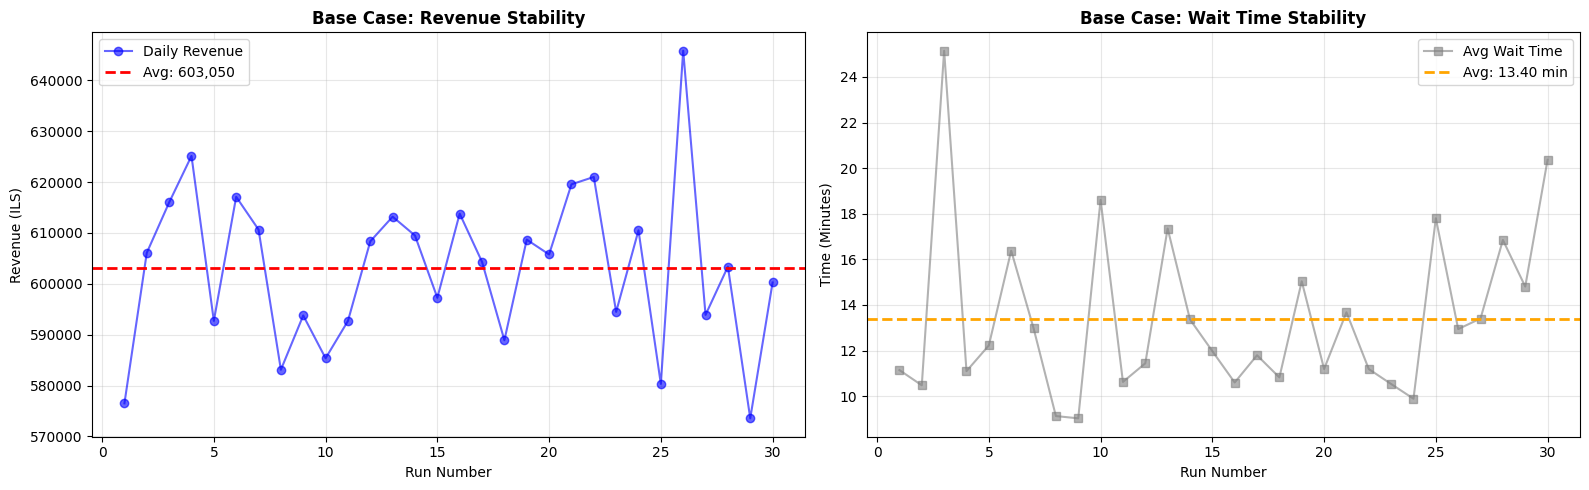

   -> Base Avg Revenue: 603,050.00
   -> Base Avg Wait Time: 13.40 min


In [ ]:
# ==========================================
# STEP 2: Running Full Base Case
# ==========================================
print(f"\n🔵 STEP 2: Running Full Base Case (N={final_n})")

# Config is empty for Base Case
base_revs, base_waits = run_batch(final_n, config={}, start_seed=100)

# Plot
plot_scenario_metrics(base_revs, base_waits, "Base Case", color_main='blue')

# Save averages for later
avg_base_rev = np.mean(base_revs)
avg_base_wait = np.mean(base_waits)

print(f"   -> Base Avg Revenue: {avg_base_rev:,.2f}")
print(f"   -> Base Avg Wait Time: {avg_base_wait:.2f} min")

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

---

### **חלופה א': שדרוג חוויית השירות ומיומנות כוח האדם**

במסגרת חלופה זו, בוצעה הרצה של המודל תוך הטמעת שיפורים הממוקדים בייעול זמני השירות והעלאת שביעות רצון האורחים. השינויים המרכזיים כוללים:

* **הקמת אתר אינטרנט:** מעבר לרכישה מוקדמת המפחיתה את העומס בתורי הקבלה ומקצרת את זמן השהייה בכניסה לפארק.
* **ייעול מערך המזון:** שדרוג המטבח לצוות מיומן ומהיר יותר, המאפשר צמצום משמעותי בזמני ההמתנה לאוכל.
* **הטבת מבקרים:** הטמעה של מנגנון הטבות ייעודי שנועד לשפר את הדירוג הקבוצתי ולהגדיל את ההוצאה הממוצעת של האורחים.

 וזאת עבור עלות כוללת של 250,000 ש"ח


מטרת הרצה זו היא לבחון האם השקעה בהכשרת צוות ובפתרונות שירות דיגיטליים מצדיקה את עצמה במונחי הכנסה וצמצום נטישת תורים.

---

</div>

Streaming output truncated to the last 5000 lines.
--------------------------------------------------

[19:00] DEPARTURE: Teenagers #146166 (EXPRESS) is leaving
      --- Individual Photo Summary ---
      > Age: 15 | Rank: 10.90 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 14 | Rank: 10.90 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 15 | Rank: 11.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 14 | Rank: 10.90 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 16 | Rank: 10.90 | Bought: 10 Photos + Video (+120 NIS)
      >>> Total Photo Sales for Group: 600 NIS
--------------------------------------------------

[19:00] DEPARTURE: single #146722 is leaving
      --- Individual Photo Summary ---
      > Age: 51 | Rank: 9.38 | Bought: 10 Photos + Video (+120 NIS)
      >>> Total Photo Sales for Group: 120 NIS
--------------------------------------------------

[19:00] DEPARTURE: Teenagers #146830 (EXPRESS) is leaving
      --- Individual Photo Summary ---
      > 

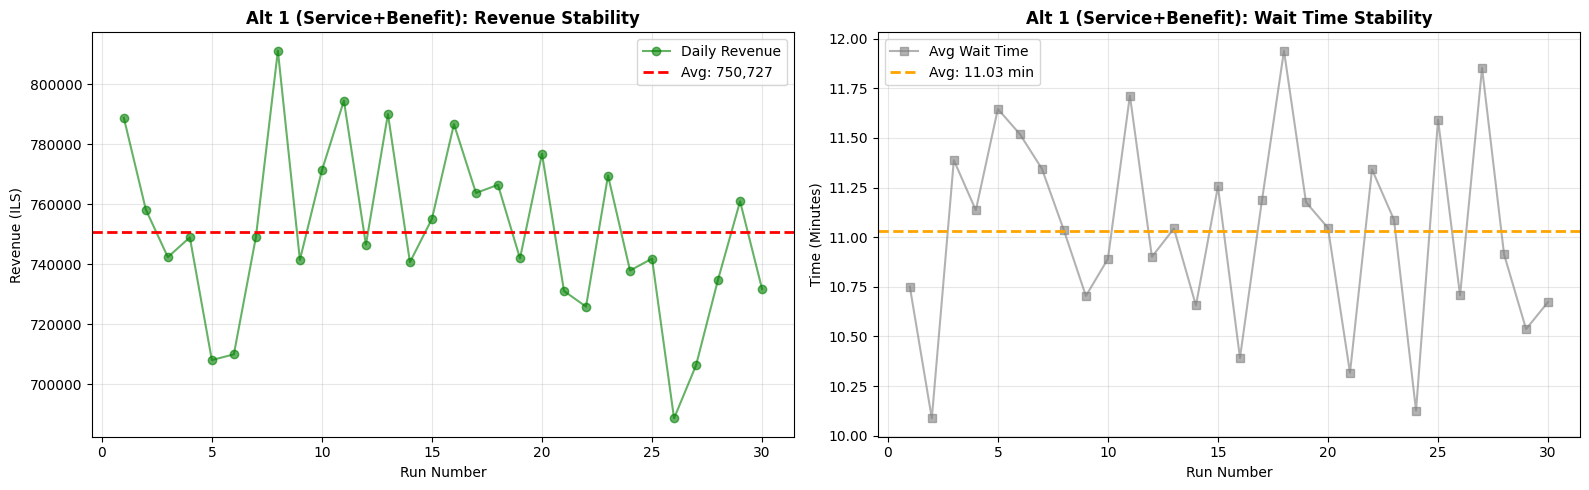

   -> Alt 1 Avg Revenue: 750,726.83
   -> Alt 1 Avg Wait Time: 11.03 min


In [ ]:
# ==========================================
# STEP 3A: Analyzing Alternative 1 (Service + Benefit)
# ==========================================
print(f"\n STEP 3A: Alternative 1 (Service Upgrade) (N={final_n})")

# Config: Website + Better Kitchen + VISITOR BENEFIT
config_alt1 = {
    "WEB_WEBSITE": True,
    "BETTER_KITCHEN": True,
    "VISITOR_BENEFIT": True
}

# Run
alt1_revs, alt1_waits = run_batch(final_n, config=config_alt1, start_seed=100)

# Plot (Green)
plot_scenario_metrics(alt1_revs, alt1_waits, "Alt 1 (Service+Benefit)", color_main='green')

print(f"   -> Alt 1 Avg Revenue: {np.mean(alt1_revs):,.2f}")
print(f"   -> Alt 1 Avg Wait Time: {np.mean(alt1_waits):.2f} min")

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

---

### **חלופה ב': הגדלת קיבולת תשתיתית ושיפור זרימה**

בחלופה זו, המודל מתמקד בשיפור היכולת התפעולית של מתקני הליבה בפארק לצד המעבר לשירות דיגיטלי. השינויים המרכזיים כוללים:

* **הקמת אתר אינטרנט:** בדומה לחלופה א', הקטנת צווארי הבקבוק בעמדות הכניסה לפארק.
* **הרחבת קיבולת המגלשות:** הגדלת מספר האבובים במגלשה הגדולה מ-8 ל-10 יחידות פעילות בו-זמנית.

 וזאת עבור עלות כוללת של 250,000 ש"ח


מטרת הרצה זו היא לבדוק האם הוספת משאבים פיזיים (קיבולת במתקן פופולרי) היא הפתרון היעיל ביותר להורדת זמני ההמתנה בתורים הרגילים והאם היא מובילה לגידול משמעותי בהכנסות ביחס למודל הבסיס.

---

</div>

Streaming output truncated to the last 5000 lines.
      > Age: 17 | Rank: 9.70 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 17 | Rank: 9.80 | Bought: 10 Photos + Video (+120 NIS)
      >>> Total Photo Sales for Group: 600 NIS
--------------------------------------------------

[19:00] DEPARTURE: Teenagers #214209 (EXPRESS) is leaving
      --- Individual Photo Summary ---
      > Age: 17 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 15 | Rank: 9.37 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 14 | Rank: 9.90 | Bought: 10 Photos + Video (+120 NIS)
      >>> Total Photo Sales for Group: 360 NIS
--------------------------------------------------

[19:00] DEPARTURE: Teenagers #214703 (EXPRESS) is leaving
      --- Individual Photo Summary ---
      > Age: 17 | Rank: 9.90 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 15 | Rank: 9.90 | Bought: 10 Photos + Video (+120 NIS)
      > Age: 15 | Rank: 10.00 | Bought: 10 Photos + Video (+120 NIS)
      > Age

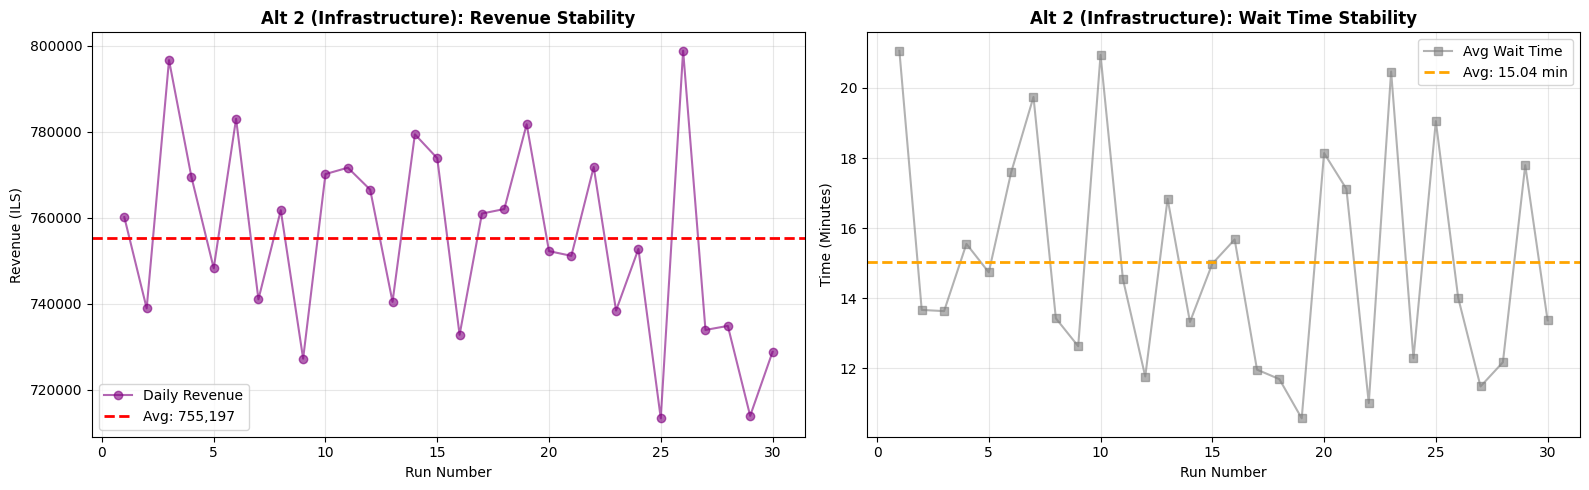

   -> Alt 2 Avg Revenue: 755,196.83
   -> Alt 2 Avg Wait Time: 15.04 min


In [ ]:
# ==========================================
# STEP 3B: Analyzing Alternative 2
# ==========================================
print(f"\n STEP 3B: Alternative 2 (Infrastructure) (N={final_n})")

# Config: Website + Bigger Tubes
config_alt2 = {"WEB_WEBSITE": True, "BIGGER_TUBES": True}

# Run
alt2_revs, alt2_waits = run_batch(final_n, config=config_alt2, start_seed=100)

# Plot (Purple)
plot_scenario_metrics(alt2_revs, alt2_waits, "Alt 2 (Infrastructure)", color_main='purple')

print(f"   -> Alt 2 Avg Revenue: {np.mean(alt2_revs):,.2f}")
print(f"   -> Alt 2 Avg Wait Time: {np.mean(alt2_waits):.2f} min")

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

---

### **ניתוח סטטיסטי השוואתי באמצעות מבחן T מזווג (Paired T-Test)**

כדי לקבוע האם השינויים התפעוליים שהצענו אכן מביאים לשיפור מובהק במדדי הפארק, ביצענו ניתוח סטטיסטי מעמיק המבוסס על **מבחן T למדגמים מזווגים**. בשיטה זו, עבור כל אחד מהמדדים (זמני המתנה והכנסות), הגדרנו משתנה מקרי חדש המייצג את ההפרש בין תוצאות ריצת הסימולציה בחלופה המוצעת לבין תוצאות אותה הריצה בדיוק במודל הקיים (Base Case).

הניתוח כלל שלוש השוואות מרכזיות לכל מדד:
1. **חלופה א' מול המצב הקיים:** בחינת האפקטיביות של פתיחת אתר אינטרנט, שדרוג המטבח והטבת המבקרים.
2. **חלופה ב' מול המצב הקיים:** בחינת האפקטיביות של הקמת אתר אינטרנט והגדלת קיבולת האבובים.
3. **השוואה ישירה בין חלופה א' לחלופה ב':** במטרה לזהות איזו מבין שתי ההצעות מניבה את התוצאה האופטימלית עבור הפארק.

#### **הנחות היסוד לביצוע המבחן:**
לצורך קבלת מסקנות תקפות ממבחן ה-T המזווג, הנחנו את ההנחות הבאות:
* **תלות בין הריצות:** קיימת תלות בין ריצות מקבילות בשתי הסדרות (הנובעת משימוש במספרים אקראיים משותפים לצורך השוואה מבוקרת)- SEED משותף.
* **אי-תלות פנימית:** אין תלות בין ריצות שונות בתוך כל חלופה בפני עצמה- שינוי הSEED בין ההרצות.
* **התפלגות נורמלית:** התוצאות (ממוצעי ההפרשים) מתפלגות נורמלית, בהתאם למשפט הגבול המרכזי וגודל המדגם שנבחר ($N=30$).

במסגרת הניתוח, חישבנו עבור כל השוואה את **רווח הסמך (Confidence Interval)** להפרש הממוצע. הבדיקה התבססה על בחינת מיקומו של הערך "0" ביחס לרווח הסמך: במידה והערך 0 נמצא בתוך הטווח, הסקנו כי אין הבדל מובהק סטטיסטית בין החלופות. לעומת זאת, אם הערך 0 נמצא מחוץ לרווח הסמך, הדבר מעיד על **שינוי מובהק** לטובה או לרעה. כדי להבטיח את אמינות המסקנות ונוכח ביצוע מספר רב של השוואות, השתמשנו ב**תיקון בונפרוני (Bonferroni Correction)**. תיקון זה החמיר את רמת המובהקות לכל בדיקה בנפרד ($\alpha=0.0166$), ובכך מנע הצטברות של טעויות סטטיסטיות ושמר על רמת ביטחון כוללת של 90% לכלל הניתוח.

---

</div>

In [ ]:
# ==========================================
# STEP 5: Detailed Z-Table Analysis & Confidence Intervals
# ==========================================
import numpy as np
import scipy.stats as stats

print("\n STEP 5: Final Detailed Analysis (The 'Z' Table)")
print("=" * 80)

# --- Bonferroni Settings (As requested) ---
alpha_total = 0.1       # Significance level 90%
num_tests = 6           # 6 Total comparisons
alpha_adj = alpha_total / num_tests
print(f"  Bonferroni Settings: Alpha Total={alpha_total} | Tests={num_tests}")
print(f"    >>> Adjusted Alpha (per test): {alpha_adj:.5f}")

def print_detailed_z_table(name_a, data_a, name_b, data_b, metric_name):
    """
    Prints a table showing the difference (Z) for each run,
    followed by the summary statistics.
    """
    n = len(data_a)
    diffs = [] # List to store differences (Z values)

    print(f"\n\n COMPARISON: {name_a} vs {name_b} ({metric_name})")
    print("-" * 75)
    # Table Headers
    print(f"{'Run':<5} | {name_a[:15]:<18} | {name_b[:15]:<18} | {'Diff (Z)':<15}")
    print("-" * 75)

    # 1. Print table row by row
    for i in range(n):
        val_a = data_a[i]
        val_b = data_b[i]
        z = val_a - val_b # Calculate difference
        diffs.append(z)

        # Print (Different formatting for Money vs Time)
        if metric_name == "Revenue":
            print(f"{i+1:<5} | {val_a:<18,.0f} | {val_b:<18,.0f} | {z:<15,.0f}")
        else:
            print(f"{i+1:<5} | {val_a:<18.2f} | {val_b:<18.2f} | {z:<15.2f}")

    # 2. Calculate Summary Statistics
    mean_z = np.mean(diffs)
    std_z = np.std(diffs, ddof=1)
    se_z = std_z / np.sqrt(n) # Standard Error

    # Critical T-Value adjusted for Bonferroni
    t_crit = stats.t.ppf(1 - alpha_adj/2, df=n-1)

    # Confidence Interval Limits (Half Width)
    hw = t_crit * se_z
    ci_lower = mean_z - hw
    ci_upper = mean_z + hw

    # 3. Print Summary
    print("-" * 75)
    print(f"STATS SUMMARY:")
    print(f" • Mean Diff (Z̄):      {mean_z:,.2f}")
    print(f" • Std Dev (S_z):      {std_z:,.2f}")
    print(f" • Standard Error:     {se_z:,.2f}")
    print(f" • T-Critical (adj):   {t_crit:.3f}")
    print(f" • Confidence Interval:[{ci_lower:,.2f}, {ci_upper:,.2f}]")
    print("-" * 75)

    # 4. Check Winner (Is 0 inside the interval?)
    zero_inside = (ci_lower <= 0 <= ci_upper)

    if zero_inside:
        print(" RESULT: 0 is INSIDE the interval --> NO Significant Difference.")
    else:
        print(" RESULT: 0 is OUTSIDE the interval --> SIGNIFICANT DIFFERENCE!")

        # Who is the winner?
        if metric_name == "Revenue":
            # For Revenue: If diff is positive (A-B > 0), A wins
            winner = name_a if mean_z > 0 else name_b
        else:
            # For Wait Time: If diff is negative (A-B < 0), A wins (Lower is better)
            winner = name_a if mean_z < 0 else name_b

        print(f" WINNER: {winner}")
    print("=" * 75)

# ==========================================
# Run Comparisons (Only main ones to avoid clutter)
# ==========================================

# 1. Wait Time Analysis (Lower = Better)
print("\n" + "▒"*30 + " WAIT TIME ANALYSIS " + "▒"*30)
print_detailed_z_table("Alt 1", alt1_waits, "Base", base_waits, "Wait Time")
print_detailed_z_table("Alt 2", alt2_waits, "Base", base_waits, "Wait Time")

# 2. Revenue Analysis (Higher = Better)
print("\n" + "▒"*30 + " REVENUE ANALYSIS " + "▒"*30)
print_detailed_z_table("Alt 1", alt1_revs, "Base", base_revs, "Revenue")
print_detailed_z_table("Alt 2", alt2_revs, "Base", base_revs, "Revenue")

# 3. Comparison between Alternatives (To see which upgrade is better)
print("\n" + "▒"*30 + " ALT 1 vs ALT 2 " + "▒"*30)
print_detailed_z_table("Alt 1", alt1_waits, "Alt 2", alt2_waits, "Wait Time")
print_detailed_z_table("Alt 1", alt1_revs, "Alt 2", alt2_revs, "Revenue")


 STEP 5: Final Detailed Analysis (The 'Z' Table)
  Bonferroni Settings: Alpha Total=0.1 | Tests=6
    >>> Adjusted Alpha (per test): 0.01667

▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒ WAIT TIME ANALYSIS ▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒


 COMPARISON: Alt 1 vs Base (Wait Time)
---------------------------------------------------------------------------
Run   | Alt 1              | Base               | Diff (Z)       
---------------------------------------------------------------------------
1     | 10.75              | 11.14              | -0.39          
2     | 10.09              | 10.48              | -0.39          
3     | 11.39              | 25.15              | -13.76         
4     | 11.14              | 11.10              | 0.04           
5     | 11.65              | 12.23              | -0.58          
6     | 11.52              | 16.38              | -4.86          
7     | 11.34              | 12.98              | -1.64          
8     | 11.03              | 9.13               | 1.91 

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

---

### **ניתוח תוצאות והסקה סטטיסטית**

לאחר ביצוע 30 הרצות לכל חלופה ובחינתן באמצעות מבחן T מזווג עם תיקון בונפרוני, להלן הממצאים המרכזיים עבור מדדי הביצוע:

1. **ניתוח זמני המתנה (Wait Time):**
* **חלופה א' מול המצב הקיים:** נמצא שיפור מובהק סטטיסטית (0 נמצא מחוץ לרווח הסמך $[-4.06, -0.67]$). זמן ההמתנה הממוצע ירד ב-2.36 יחידות זמן, מה שמעיד על יעילות גבוהה של שדרוג המטבח והשירות הדיגיטלי בצמצום תורים.
* **חלופה ב' מול המצב הקיים:** לא נמצא הבדל מובהק סטטיסטית (0 נמצא בתוך רווח הסמך $[-0.45, 3.74]$). למרות הגדלת מספר האבובים, השיפור בתשתית לא הצליח להוריד את זמני ההמתנה באופן עקבי ומובהק.
* **השוואה בין החלופות:** חלופה א' ניצחה באופן מובהק את חלופה ב', עם הפרש ממוצע של 4.01 לטובתה.

2. **ניתוח הכנסות (Revenue):**
* **שתי החלופות (א' ו-ב')** הציגו שיפור מובהק ומרשים לעומת המצב הקיים. חלופה א' הניבה תוספת ממוצעת של כ-147,676 ש"ח, בעוד חלופה ב' הניבה כ-152,146 ש"ח.
* **השוואה בין החלופות:** בהשוואה ישירה בין חלופה א' ל-ב' בנושא הכנסות, **לא נמצא הבדל מובהק** (0 נמצא בתוך רווח הסמך). כלומר, מבחינה כלכלית טהורה, שתי החלופות תורמות לקופת הפארק באופן דומה מאוד.

---

### **מסקנה סופית והמלצה תפעולית**

לאור הנתונים, **החלופה המנצחת היא חלופה א'**.
למרות ששתי החלופות מגדילות את הכנסות הפארק במידה דומה, חלופה א' (אתר אינטרנט, מטבח מיומן והטבת מבקרים) היא היחידה שהצליחה להוביל ל**שיפור מובהק ומשמעותי בחוויית הלקוח** דרך קיצור זמני ההמתנה בתור הרגיל. הגדלת הקיבולת הפיזית במגלשות (חלופה ב') התבררה כפחות אפקטיבית בניהול העומסים הכולל.

**המלצתנו:** להשקיע בשדרוג מיומנות כוח האדם במטבח ובמערכות דיגיטליות (חלופה א'), שכן היא מספקת את המענה הטוב ביותר לאופטימיזציה בין רווחיות הפארק לשביעות רצון המבקרים.

---

</div>